In [2]:
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import Point

# 데이터 로드 및 구성요소 확인

In [3]:
df = pd.read_csv("./원본데이터/road_data_v1_final.csv")
print(df.shape)
print(df.columns.tolist())
print(df.dtypes)

(2191, 17)
['DTCT_UID', 'PLC_LTTD', 'PLC_LGTD', 'ROAD_INFO', 'DSTA_LGLD_INFO', 'DSTA_ADSTRD_INFO', 'DTCT_PD', 'ROAD_WIDTH', 'POTHOLE_SIZE', 'u', 'v', 'key', 'highway', 'dist_to_road', 'OSM_HIGHWAY', 'OSM_DIST', 'ROAD_LEVEL']
DTCT_UID              int64
PLC_LTTD            float64
PLC_LGTD            float64
ROAD_INFO            object
DSTA_LGLD_INFO       object
DSTA_ADSTRD_INFO     object
DTCT_PD              object
ROAD_WIDTH            int64
POTHOLE_SIZE        float64
u                     int64
v                     int64
key                   int64
highway              object
dist_to_road        float64
OSM_HIGHWAY          object
OSM_DIST            float64
ROAD_LEVEL           object
dtype: object


In [4]:
df.head(3)

,DTCT_UID,PLC_LTTD,PLC_LGTD,ROAD_INFO,DSTA_LGLD_INFO,DSTA_ADSTRD_INFO,DTCT_PD,ROAD_WIDTH,POTHOLE_SIZE,u,v,key,highway,dist_to_road,OSM_HIGHWAY,OSM_DIST,ROAD_LEVEL
0,1,36.308420,127.354424,대전광역시 서구 도안동 2088,도안동,도안동,2025-12-09 22:50,8,12.8,1298415193,1298414556,0,residential,1.640233,residential,1.640233,소로
1,2,36.308420,127.354424,대전광역시 서구 도안동 2088,도안동,도안동,2025-12-09 22:50,8,10.2,1298414556,1298415193,0,residential,1.640233,residential,1.640233,소로
2,3,36.309225,127.354056,대전광역시 서구 도안동 2088,도안동,도안동,2025-12-09 22:49,8,11.6,1298414556,1298415297,0,residential,3.648603,residential,3.648603,소로


In [5]:
import geopandas as gpd
gdf = gpd.read_file("./원본데이터/yuseong_road_slim.geojson")
print(gdf.shape)
print(gdf.columns.tolist())
print("CRS:", gdf.crs)
print(gdf.geometry.type.value_counts())

(4430, 33)
['section_id', 'sub_id', 'length_m', 'ALWNC_DE', 'ALWNC_RESN', 'BSI_INT', 'ENG_RN', 'MVMN_DE', 'MVMN_RESN', 'MVM_RES_CD', 'NTFC_DE', 'OPERT_DE', 'RBP_CN', 'RDS_DPN_SE', 'RDS_MAN_NO', 'REP_CN', 'RN', 'RN_CD', 'ROAD_BT', 'ROAD_LT', 'ROA_CLS_SE', 'SIG_CD', 'WDR_RD_CD', 'road_id', 'road_length_m', 'section_order', 'lat', 'lon', 'lat_start', 'lon_start', 'lat_end', 'lon_end', 'geometry']
CRS: EPSG:4326
LineString    4430
Name: count, dtype: int64


In [6]:
gdf.head(3)

,section_id,sub_id,length_m,ALWNC_DE,ALWNC_RESN,BSI_INT,ENG_RN,MVMN_DE,MVMN_RESN,MVM_RES_CD,...,road_id,road_length_m,section_order,lat,lon,lat_start,lon_start,lat_end,lon_end,geometry
0,1000013_000,1000013_000_1,2312.283384,20101228,국토해양부 노선명을 이용하여 명명함,2000,Honamjiseon Expressway,20141030,직권수정(속성변경),99,...,000000,2312.283384,0,36.272648,127.298698,36.265368,127.291148,36.275418,127.309230,"LINESTRING (127.29115 36.26537, 127.29161 36.2..."
1,1000013_001,1000013_001_1,4245.580726,20101228,국토해양부 노선명을 이용하여 명명함,2000,Honamjiseon Expressway,20141030,직권수정(속성변경),99,...,000001,20056.471214,1,36.303630,127.311569,36.285706,127.316592,36.321769,127.308652,"LINESTRING (127.31659 36.28571, 127.31679 36.2..."
2,1000013_001,1000013_001_2,2628.181975,20101228,국토해양부 노선명을 이용하여 명명함,2000,Honamjiseon Expressway,20141030,직권수정(속성변경),99,...,000001,20056.471214,1,36.332785,127.314135,36.321769,127.308652,36.343337,127.320549,"LINESTRING (127.30865 36.32177, 127.31057 36.3..."


# 섹션 -> 서브섹션 단위 분할

## 100m 단위 분할

In [7]:
import geopandas as gpd
from shapely.geometry import LineString
from shapely.ops import substring

CRS_WGS84 = "EPSG:4326"
CRS_M = "EPSG:5186"

SEG_LEN_M = 100  # 서브섹션 길이 (m)

# 1) 원본 도로 로드
gdf = gpd.read_file("./원본데이터/yuseong_road_slim.geojson")
gdf = gdf.to_crs(CRS_M)

def split_linestring_by_length(ls: LineString, seg_len: float):
    L = ls.length
    if L == 0:
        return []
    out = []
    start = 0.0
    i = 0
    while start < L:
        end = min(start + seg_len, L)
        seg = substring(ls, start, end)
        if not seg.is_empty and seg.length > 0:
            out.append((i, seg))
        i += 1
        start = end
    return out

# 2) 서브섹션 생성
rows = []
for _, r in gdf.iterrows():
    section_id = r["section_id"]
    geom = r.geometry

    if geom is None or geom.is_empty:
        continue

    if geom.geom_type == "LineString":
        parts = [geom]
    elif geom.geom_type == "MultiLineString":
        parts = list(geom.geoms)
    else:
        continue

    part_no = 0
    for ls in parts:
        for seg_idx, seg in split_linestring_by_length(ls, SEG_LEN_M):
            rows.append({
                "section_id": section_id,
                "part_no": part_no,
                "seg_idx": seg_idx,
                "sub_section_id": f"{section_id}_p{part_no:02d}_s{seg_idx:04d}",
                "length_m": round(seg.length, 2),
                "geometry": seg
            })
        part_no += 1

# 3) GeoDataFrame 생성 (Kepler용 WGS84)
gdf_sub = gpd.GeoDataFrame(rows, crs=CRS_M).to_crs(CRS_WGS84)

print("서브섹션 수:", len(gdf_sub))
print(gdf_sub.head())

# 4) GeoJSON 저장
out_path = "./전처리데이터/yuseong_road_subsection_100m.geojson"
gdf_sub.to_file(out_path, driver="GeoJSON")

print("저장 완료:", out_path)

서브섹션 수: 11240
    section_id  part_no  seg_idx         sub_section_id  length_m  \
0  1000013_000        0        0  1000013_000_p00_s0000     100.0   
1  1000013_000        0        1  1000013_000_p00_s0001     100.0   
2  1000013_000        0        2  1000013_000_p00_s0002     100.0   
3  1000013_000        0        3  1000013_000_p00_s0003     100.0   
4  1000013_000        0        4  1000013_000_p00_s0004     100.0   

                                            geometry  
0  LINESTRING (127.29115 36.26537, 127.29161 36.2...  
1  LINESTRING (127.29168 36.26615, 127.29179 36.2...  
2  LINESTRING (127.29212 36.26698, 127.2923 36.26...  
3  LINESTRING (127.29255 36.26781, 127.29294 36.2...  
4  LINESTRING (127.29294 36.26866, 127.29295 36.2...  
저장 완료: ./전처리데이터/yuseong_road_subsection_100m.geojson


## 200m 단위 분할

In [8]:
import geopandas as gpd
from shapely.geometry import LineString
from shapely.ops import substring

CRS_WGS84 = "EPSG:4326"
CRS_M = "EPSG:5186"

SEG_LEN_M = 200  # 200m 기준

# 1) 원본 도로 로드
gdf = gpd.read_file("./원본데이터/yuseong_road_slim.geojson")
gdf = gdf.to_crs(CRS_M)

def split_linestring_by_length(ls: LineString, seg_len: float):
    L = ls.length
    if L == 0:
        return []
    out = []
    start = 0.0
    i = 0
    while start < L:
        end = min(start + seg_len, L)
        seg = substring(ls, start, end)
        if not seg.is_empty and seg.length > 0:
            out.append((i, seg))
        i += 1
        start = end
    return out

# 2) 서브섹션 생성
rows = []
for _, r in gdf.iterrows():
    section_id = r["section_id"]
    geom = r.geometry

    if geom is None or geom.is_empty:
        continue

    if geom.geom_type == "LineString":
        parts = [geom]
    elif geom.geom_type == "MultiLineString":
        parts = list(geom.geoms)
    else:
        continue

    part_no = 0
    for ls in parts:
        for seg_idx, seg in split_linestring_by_length(ls, SEG_LEN_M):
            rows.append({
                "section_id": section_id,
                "part_no": part_no,
                "seg_idx": seg_idx,
                "sub_section_id": f"{section_id}_p{part_no:02d}_s{seg_idx:04d}",
                "length_m": round(seg.length, 2),
                "geometry": seg
            })
        part_no += 1

# 3) GeoDataFrame 생성 (WGS84)
gdf_sub_200m = gpd.GeoDataFrame(rows, crs=CRS_M).to_crs(CRS_WGS84)

print("서브섹션 수:", len(gdf_sub_200m))
print(gdf_sub_200m.head())

# 4) GeoJSON 저장
out_path = "./전처리데이터/yuseong_road_subsection_200m.geojson"
gdf_sub_200m.to_file(out_path, driver="GeoJSON")

print("저장 완료:", out_path)

서브섹션 수: 7004
    section_id  part_no  seg_idx         sub_section_id  length_m  \
0  1000013_000        0        0  1000013_000_p00_s0000     200.0   
1  1000013_000        0        1  1000013_000_p00_s0001     200.0   
2  1000013_000        0        2  1000013_000_p00_s0002     200.0   
3  1000013_000        0        3  1000013_000_p00_s0003     200.0   
4  1000013_000        0        4  1000013_000_p00_s0004     200.0   

                                            geometry  
0  LINESTRING (127.29115 36.26537, 127.29161 36.2...  
1  LINESTRING (127.29212 36.26698, 127.2923 36.26...  
2  LINESTRING (127.29294 36.26866, 127.29295 36.2...  
3  LINESTRING (127.29367 36.27036, 127.29371 36.2...  
4  LINESTRING (127.29436 36.27207, 127.29454 36.2...  
저장 완료: ./전처리데이터/yuseong_road_subsection_200m.geojson


# 파손 데이터 매칭 후 라벨 비율 계산

## 200m 기준

In [9]:
import pandas as pd
import geopandas as gpd

CRS_WGS84 = "EPSG:4326"
CRS_M = "EPSG:5186"
MAX_DIST_M = 30  # 매칭 허용 최대 거리

# 1) 파손 이벤트 로드
df_evt = pd.read_csv("./원본데이터/road_data_v1_final.csv")
df_evt["DTCT_PD"] = pd.to_datetime(df_evt["DTCT_PD"], errors="coerce")
df_evt = df_evt.dropna(subset=["PLC_LTTD", "PLC_LGTD", "DTCT_PD"])
df_evt = df_evt.drop_duplicates(subset=["DTCT_UID"])
df_evt["event_month"] = df_evt["DTCT_PD"].dt.to_period("M").dt.to_timestamp()

gdf_evt = gpd.GeoDataFrame(
    df_evt,
    geometry=gpd.points_from_xy(df_evt["PLC_LGTD"], df_evt["PLC_LTTD"]),
    crs=CRS_WGS84
)

# 2) 200m 서브섹션 로드
gdf_sub = gpd.read_file("./전처리데이터/yuseong_road_subsection_200m.geojson")

# CRS 통일
gdf_evt_m = gdf_evt.to_crs(CRS_M)
gdf_sub_m = gdf_sub.to_crs(CRS_M)

# 3) 최근접 매칭
gdf_match_200m = gpd.sjoin_nearest(
    gdf_evt_m,
    gdf_sub_m[["sub_section_id", "geometry"]],
    how="left",
    distance_col="dist_m"
)

# 거리 컷
gdf_match_200m = gdf_match_200m[
    gdf_match_200m["dist_m"].notna() &
    (gdf_match_200m["dist_m"] <= MAX_DIST_M)
].copy()

print("200m 매칭 이벤트 수:", len(gdf_match_200m))

200m 매칭 이벤트 수: 1439


In [10]:
panel_200m = (
    gdf_match_200m
    .groupby(["sub_section_id", "event_month"])
    .size()
    .reset_index(name="event_cnt")
    .sort_values(["sub_section_id", "event_month"])
)

print("200m 패널 크기:", panel_200m.shape)
panel_200m.head()

200m 패널 크기: (612, 3)


,sub_section_id,event_month,event_cnt
0,1000013_001_p00_s0001,2024-03-01,2
1,1000013_001_p00_s0003,2024-04-01,1
2,1000015_000_p00_s0003,2025-12-01,2
3,1000015_000_p00_s0006,2025-01-01,2
4,1000015_000_p00_s0007,2025-01-01,1


In [11]:
# 다음 달 키 생성
panel_200m["next_month"] = (
    panel_200m["event_month"] + pd.offsets.MonthBegin(1)
).dt.to_period("M").dt.to_timestamp()

# 다음달 이벤트 매칭
next_evt = panel_200m[["sub_section_id", "event_month", "event_cnt"]].rename(
    columns={
        "event_month": "next_month",
        "event_cnt": "next_event_cnt"
    }
)

panel_200m = panel_200m.merge(
    next_evt,
    on=["sub_section_id", "next_month"],
    how="left"
)

panel_200m["next_event_cnt"] = panel_200m["next_event_cnt"].fillna(0).astype(int)
panel_200m["target_next_month"] = (panel_200m["next_event_cnt"] > 0).astype(int)

# 라벨 비율
print("200m 라벨 분포:")
print(panel_200m["target_next_month"].value_counts())
print(panel_200m["target_next_month"].value_counts(normalize=True))

200m 라벨 분포:
target_next_month
0    512
1    100
Name: count, dtype: int64
target_next_month
0    0.836601
1    0.163399
Name: proportion, dtype: float64


## 100m 기준

In [12]:
# 100m 서브섹션 로드
gdf_sub_100m = gpd.read_file("./전처리데이터/yuseong_road_subsection_100m.geojson")

gdf_sub_100m_m = gdf_sub_100m.to_crs(CRS_M)

gdf_match_100m = gpd.sjoin_nearest(
    gdf_evt_m,
    gdf_sub_100m_m[["sub_section_id", "geometry"]],
    how="left",
    distance_col="dist_m"
)

gdf_match_100m = gdf_match_100m[
    gdf_match_100m["dist_m"].notna() &
    (gdf_match_100m["dist_m"] <= MAX_DIST_M)
].copy()

print("100m 매칭 이벤트 수:", len(gdf_match_100m))

100m 매칭 이벤트 수: 1439


In [13]:
panel_100m = (
    gdf_match_100m
    .groupby(["sub_section_id", "event_month"])
    .size()
    .reset_index(name="event_cnt")
    .sort_values(["sub_section_id", "event_month"])
)

print("100m 패널 크기:", panel_100m.shape)
panel_100m.head()

100m 패널 크기: (697, 3)


,sub_section_id,event_month,event_cnt
0,1000013_001_p00_s0002,2024-03-01,2
1,1000013_001_p00_s0006,2024-04-01,1
2,1000013_001_p00_s0007,2024-02-01,1
3,1000015_000_p00_s0006,2025-12-01,2
4,1000015_000_p00_s0013,2025-01-01,2


In [14]:
panel_100m["next_month"] = (
    panel_100m["event_month"] + pd.offsets.MonthBegin(1)
).dt.to_period("M").dt.to_timestamp()

next_evt_100m = panel_100m[["sub_section_id", "event_month", "event_cnt"]].rename(
    columns={
        "event_month": "next_month",
        "event_cnt": "next_event_cnt"
    }
)

panel_100m = panel_100m.merge(
    next_evt_100m,
    on=["sub_section_id", "next_month"],
    how="left"
)

panel_100m["next_event_cnt"] = panel_100m["next_event_cnt"].fillna(0).astype(int)
panel_100m["target_next_month"] = (panel_100m["next_event_cnt"] > 0).astype(int)

print("100m 라벨 분포:")
print(panel_100m["target_next_month"].value_counts())
print(panel_100m["target_next_month"].value_counts(normalize=True))

100m 라벨 분포:
target_next_month
0    609
1     88
Name: count, dtype: int64
target_next_month
0    0.873745
1    0.126255
Name: proportion, dtype: float64


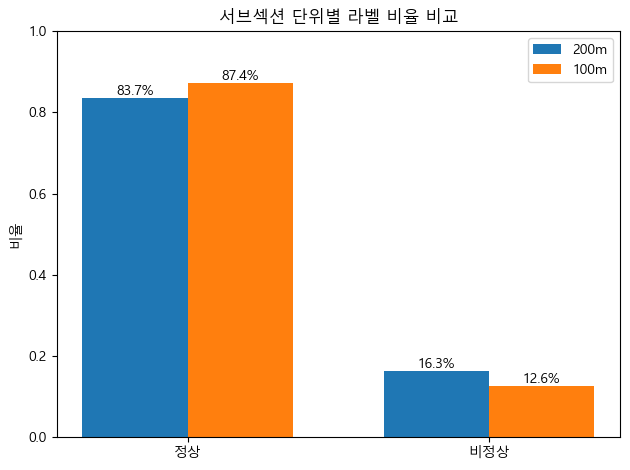

In [23]:
ratio_200m = [0.836601, 0.163399]
ratio_100m = [0.873745, 0.126255]

import numpy as np
x = np.array([0, 1])  # x = np.arange(2) 도 가능

import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

plt.figure()
plt.bar(x - width/2, ratio_200m, width, label="200m")
plt.bar(x + width/2, ratio_100m, width, label="100m")

plt.xticks(x, labels)
plt.ylabel("비율")
plt.ylim(0, 1)
plt.title("서브섹션 단위별 라벨 비율 비교")
plt.legend()

for i, v in enumerate(ratio_200m):
    plt.text(i - width/2, v, f"{v*100:.1f}%", ha="center", va="bottom")

for i, v in enumerate(ratio_100m):
    plt.text(i + width/2, v, f"{v*100:.1f}%", ha="center", va="bottom")

plt.tight_layout()
plt.show()

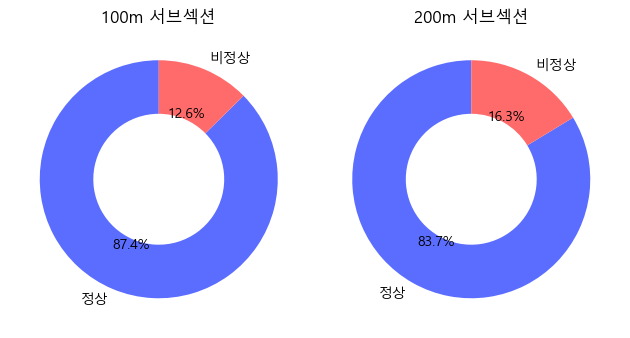

In [26]:
counts_200m = [512, 100]
counts_100m = [609, 88]
colors = ["#5B6DFF", "#FF6B6B"]

fig, axes = plt.subplots(1, 2)

axes[1].pie(
    counts_200m,
    labels=labels,
    autopct="%.1f%%",
    startangle=90,
    colors=colors,
    wedgeprops=dict(width=0.45)
)
axes[1].set_title("200m 서브섹션")

axes[0].pie(
    counts_100m,
    labels=labels,
    autopct="%.1f%%",
    startangle=90,
    colors=colors,
    wedgeprops=dict(width=0.45)
)
axes[0].set_title("100m 서브섹션")

plt.tight_layout()
plt.show()

# 기상데이터

## 기상데이터 API 호출

In [27]:
import requests
import pandas as pd
from io import StringIO

authKey = "_FW6tOhdRS2VurToXQUtMw"
stn = 133  # 대전

start_date = (
    panel_200m["event_month"].min() - pd.Timedelta(days=120)
).strftime("%Y%m%d")

end_date = (
    panel_200m["event_month"].max()
).strftime("%Y%m%d")

print("ASOS fetch range:", start_date, "~", end_date)

ASOS fetch range: 20230903 ~ 20251201


In [28]:
url = "https://apihub.kma.go.kr/api/typ01/url/kma_sfcdd3.php"
params = {
    "tm1": start_date,
    "tm2": end_date,
    "stn": stn,
    "help": 0,
    "authKey": authKey
}

resp = requests.get(url, params=params, timeout=60)
resp.encoding = resp.apparent_encoding
raw = resp.text

print(raw.splitlines()[:5])  # 헤더 확인

['#START7777', '#2345678901234567890123456789012345678901234567890123456789012345678901234567890123456789012345678901234567890123456789012345678901234567890123456789012345678901234567890123456789012345678901234567890123456789012345678901234567890123456789012345678901234567890123456789012345678901234567890123456789012345678901234567890123', '# YYMMDD STN   WS    WR  WD   WS   WS  WD   WS   WS    TA    TA   TA    TA   TA    TD    TS    TG    HM    HM   HM    PV  EV_S  EV_L    FG     PA     PS     PS   PS     PS   PS   CA   SS   SS   SS    SI    SI   SI     RN     RN    RN     RN   RN     RN   RN     RN   RN     SD   SD     SD   SD    TE    TE    TE    TE    TE', '#    KST  ID  AVG   DAY MAX  MAX  MAX INS  INS  INS   AVG   MAX  MAX   MIN  MIN   AVG   AVG   MIN   AVG   MIN  MIN   AVG               DUR    AVG    AVG    MAX  MAX    MIN  MIN  TOT  DAY  DUR  CMB   DAY   60M  60M    DAY    D99   DUR    60M  60M    10M  10M    POW  POW    NEW  NEW    MAX  MAX     5    10    15    30    50', '#  

In [29]:
lines = [
    line for line in raw.splitlines()
    if line.strip() and not line.startswith("#")
]

df_raw = pd.read_csv(
    StringIO("\n".join(lines)),
    sep=r"\s+",
    header=None
)

print("원본 ASOS shape:", df_raw.shape)
df_raw

원본 ASOS shape: (821, 56)


,0,1,2,3,4,5,6,7,8,9,...,46,47,48,49,50,51,52,53,54,55
0,20230903,133,1.5,1294,14,3.5,19,14,6.1,27,...,-9,-9.0,-9,-9.0,-9,27.6,27.4,26.9,23.5,19.1
1,20230904,133,1.2,1065,14,3.3,835,9,5.7,2345,...,-9,-9.0,-9,-9.0,-9,28.2,27.5,26.9,23.6,19.1
2,20230905,133,1.6,1366,11,3.8,1023,9,6.0,2,...,-9,-9.0,-9,-9.0,-9,28.4,27.6,26.9,23.6,19.1
3,20230906,133,1.2,1053,11,3.8,1522,11,6.3,1649,...,-9,-9.0,-9,-9.0,-9,28.5,27.8,26.9,23.6,19.2
4,20230907,133,2.3,1960,11,5.4,1437,11,9.4,1433,...,-9,-9.0,-9,-9.0,-9,28.4,27.8,26.9,23.6,19.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
816,20251127,133,2.2,1940,32,5.0,2143,34,13.2,1600,...,-9,-9.0,-9,-9.0,-9,11.9,14.4,15.7,19.5,19.8
817,20251128,133,1.7,1482,29,3.4,11,27,7.7,8,...,-9,-9.0,-9,-9.0,-9,11.2,14.1,15.9,19.7,19.9
818,20251129,133,1.4,1220,20,3.6,1333,18,7.8,1520,...,-9,-9.0,-9,-9.0,-9,10.5,13.8,15.5,19.5,19.9
819,20251130,133,1.9,1618,23,3.6,1405,25,7.7,1440,...,-9,-9.0,-9,-9.0,-9,10.9,13.6,15.7,19.7,20.1


In [30]:
df_w = df_raw[[0, 10, 11, 13, 38, 40, 45]].copy()
df_w.columns = [
    "TM",            # 관측일
    "TA_AVG",        # 평균기온
    "TA_MAX",        # 최고기온
    "TA_MIN",        # 최저기온
    "RN_DAY",        # 일강수량
    "RN_DUR",        # 강수계속시간
    "RN_POW_MAX"     # 최대강우강도
]

# 타입 변환
df_w["TM"] = pd.to_datetime(df_w["TM"], format="%Y%m%d", errors="coerce")

num_cols = ["TA_AVG", "TA_MAX", "TA_MIN", "RN_DAY", "RN_DUR", "RN_POW_MAX"]
df_w[num_cols] = df_w[num_cols].apply(pd.to_numeric, errors="coerce")

# 강수 관련: -9 → 0
rain_cols = ["RN_DAY", "RN_DUR", "RN_POW_MAX"]
for c in rain_cols:
    df_w[c] = df_w[c].replace(-9, 0)

# 온도 관련: -9 → NaN
temp_cols = ["TA_AVG", "TA_MAX", "TA_MIN"]
for c in temp_cols:
    df_w[c] = df_w[c].replace(-9, pd.NA)

print("정제된 일별 기상:", df_w.shape)
df_w

정제된 일별 기상: (821, 7)


,TM,TA_AVG,TA_MAX,TA_MIN,RN_DAY,RN_DUR,RN_POW_MAX
0,2023-09-03,27.0,32.5,22.3,0.0,0.00,0.0
1,2023-09-04,27.4,31.5,24.0,0.0,0.00,0.0
2,2023-09-05,26.9,31.2,23.8,0.0,0.00,0.0
3,2023-09-06,26.0,31.3,21.0,0.0,0.00,0.0
4,2023-09-07,25.0,30.1,19.8,0.0,0.00,0.0
...,...,...,...,...,...,...,...
816,2025-11-27,5.2,8.8,1.2,6.1,4.72,0.0
817,2025-11-28,3.7,9.0,-0.4,0.0,0.00,0.0
818,2025-11-29,6.6,15.5,-2.5,0.0,0.00,0.0
819,2025-11-30,13.9,18.4,9.3,0.0,0.00,0.0


In [31]:
df_w["month"] = df_w["TM"].dt.to_period("M").dt.to_timestamp()

weather_month = (
    df_w
    .groupby("month")
    .agg(
        rain_sum_mm=("RN_DAY", "sum"),
        rain_days=("RN_DAY", lambda x: (x > 0).sum()),
        rain_dur_hr=("RN_DUR", "sum"),
        rain_intensity_max=("RN_POW_MAX", "max"),
        temp_avg=("TA_AVG", "mean"),
        temp_min=("TA_MIN", "mean"),
        temp_max=("TA_MAX", "mean"),
    )
    .reset_index()
)

print("월별 기상 데이터:", weather_month.shape)
weather_month.head()

월별 기상 데이터: (28, 8)


,month,rain_sum_mm,rain_days,rain_dur_hr,rain_intensity_max,temp_avg,temp_min,temp_max
0,2023-09-01,310.2,11,111.00,0.0,22.753571,19.232143,27.303571
1,2023-10-01,12.2,2,14.15,0.0,15.006452,9.780645,21.419355
2,2023-11-01,40.3,9,62.58,0.0,7.593333,2.610000,13.210000
3,2023-12-01,124.1,10,117.85,0.0,2.232258,-1.987097,7.254839
4,2024-01-01,47.8,10,106.03,0.0,0.280645,-3.880645,5.293548


## 기상데이터 통계 및 적합성 확인

In [32]:
weather_month.describe()

,month,rain_sum_mm,rain_days,rain_dur_hr,rain_intensity_max,temp_avg,temp_min,temp_max
count,28,28.000000,28.000000,28.000000,28.0,28.000000,28.000000,28.000000
mean,2024-10-16 00:00:00,120.178571,9.035714,78.886071,0.0,14.489987,9.849669,19.936253
min,2023-09-01 00:00:00,0.000000,0.000000,0.000000,0.0,-0.117857,-5.085714,5.293548
25%,2024-03-24 06:00:00,34.125000,6.750000,53.922500,0.0,7.495806,2.320161,13.184677
50%,2024-10-16 12:00:00,82.100000,9.000000,78.605000,0.0,15.553226,10.043656,21.470538
75%,2025-05-08 18:00:00,146.250000,10.250000,101.357500,0.0,23.505833,19.215536,28.134167
max,2025-12-01 00:00:00,485.100000,22.000000,169.160000,0.0,28.696774,25.003226,33.532258
std,NaN,125.661884,4.176496,39.307418,0.0,9.582792,9.905847,9.364403


In [33]:
weather_month[["rain_sum_mm", "rain_days", "rain_dur_hr"]].corr()

,rain_sum_mm,rain_days,rain_dur_hr
rain_sum_mm,1.000000,0.711912,0.547293
rain_days,0.711912,1.000000,0.754326
rain_dur_hr,0.547293,0.754326,1.000000


In [34]:
def iqr_outliers(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum()

outlier_cnt = weather_month.apply(iqr_outliers)
outlier_cnt

month                 0
rain_sum_mm           2
rain_days             3
rain_dur_hr           0
rain_intensity_max    0
temp_avg              0
temp_min              0
temp_max              0
dtype: int64

In [35]:
weather_month["m"] = weather_month["month"].dt.month

weather_month.groupby("m")[[
    "rain_sum_mm",
    "temp_avg",
    "temp_min",
    "temp_max"
]].mean()

,rain_sum_mm,temp_avg,temp_min,temp_max
m,,,,
1,30.150000,0.396774,-3.972581,5.662903
2,52.500000,2.077278,-2.418719,7.454249
3,47.800000,7.920968,2.417742,14.032258
4,49.950000,15.251667,9.075000,22.020000
5,110.100000,18.214516,12.454839,24.212903
6,188.500000,24.013333,18.855000,29.725000
7,392.950000,27.440323,23.982258,31.620968
8,96.400000,28.440323,24.704839,33.201613
9,291.966667,23.956746,20.442937,28.668968


In [36]:
(weather_month == 0).mean()

month                 0.000000
rain_sum_mm           0.035714
rain_days             0.035714
rain_dur_hr           0.035714
rain_intensity_max    1.000000
temp_avg              0.000000
temp_min              0.000000
temp_max              0.000000
m                     0.000000
dtype: float64

In [37]:
panel_200m_weather = panel_200m.merge(
    weather_month.drop(columns=["rain_intensity_max"]),
    left_on="event_month",
    right_on="month",
    how="left"
)

panel_200m_weather.groupby("target_next_month")[[
    "rain_sum_mm",
    "rain_days",
    "rain_dur_hr",
    "temp_avg"
]].mean()

,rain_sum_mm,rain_days,rain_dur_hr,temp_avg
target_next_month,,,,
0,91.39043,8.884766,74.253867,10.954828
1,85.43900,9.960000,92.401200,9.471113


- 해석 포인트

① 강수량(rain_sum_mm)

target=1이 더 적음

→ “많이 비가 온 달” 자체보다
‘얼마나 자주, 오래 비가 왔는지’가 더 중요하다는 신호

② 강수일수(rain_days)

target=1이 더 많음 (≈ +1.1일)

→ 반복적 습윤 → 포장 약화 가설과 일치

③ 강수지속시간(rain_dur_hr)

target=1이 명확히 큼 (+18시간)

→ 가장 강한 신호

‘짧고 강한 비’보다 ‘오래 젖어 있는 상태’가 파손에 더 치명적

④ 평균기온(temp_avg)

target=1이 더 낮음

→ 동결·융해, 수분 잔존 가능성 ↑

## 기상 파생변수 생성

In [38]:
panel = panel_200m_weather.sort_values(
    ["sub_section_id", "event_month"]
).copy()

# 1) 최근 3개월 누적
for col in ["rain_sum_mm", "rain_days", "rain_dur_hr"]:
    panel[f"{col}_3m"] = (
        panel
        .groupby("sub_section_id")[col]
        .rolling(window=3, min_periods=1)
        .sum()
        .reset_index(level=0, drop=True)
    )

# 2) 전월 대비 변화량
panel["rain_sum_mm_diff"] = (
    panel
    .groupby("sub_section_id")["rain_sum_mm"]
    .diff()
)

panel["temp_avg_diff"] = (
    panel
    .groupby("sub_section_id")["temp_avg"]
    .diff()
)

# 3) 극한 조건 플래그
panel["freeze_month"] = (panel["temp_avg"] < 0).astype(int)

rain_day_q75 = panel["rain_days"].quantile(0.75)
panel["many_rain_days"] = (panel["rain_days"] >= rain_day_q75).astype(int)

panel.head()

,sub_section_id,event_month,event_cnt,next_month,next_event_cnt,target_next_month,month,rain_sum_mm,rain_days,rain_dur_hr,...,temp_min,temp_max,m,rain_sum_mm_3m,rain_days_3m,rain_dur_hr_3m,rain_sum_mm_diff,temp_avg_diff,freeze_month,many_rain_days
0,1000013_001_p00_s0001,2024-03-01,2,2024-04-01,0,0,2024-03-01,57.9,9,75.49,...,1.780645,13.138710,3,57.9,9.0,75.49,NaN,NaN,0,0
1,1000013_001_p00_s0003,2024-04-01,1,2024-05-01,0,0,2024-04-01,32.7,7,68.40,...,10.306667,22.566667,4,32.7,7.0,68.40,NaN,NaN,0,0
2,1000015_000_p00_s0003,2025-12-01,2,2026-01-01,0,0,2025-12-01,0.0,0,0.00,...,2.500000,13.200000,12,0.0,0.0,0.00,NaN,NaN,0,0
3,1000015_000_p00_s0006,2025-01-01,2,2025-02-01,0,0,2025-01-01,12.5,8,91.71,...,-4.064516,6.032258,1,12.5,8.0,91.71,NaN,NaN,0,0
4,1000015_000_p00_s0007,2025-01-01,1,2025-02-01,0,0,2025-01-01,12.5,8,91.71,...,-4.064516,6.032258,1,12.5,8.0,91.71,NaN,NaN,0,0


In [39]:
panel.groupby("target_next_month")[[
    "rain_days_3m",
    "rain_dur_hr_3m",
    "rain_sum_mm_3m",
    "freeze_month"
]].mean()

,rain_days_3m,rain_dur_hr_3m,rain_sum_mm_3m,freeze_month
target_next_month,,,,
0,13.777344,118.655176,138.883008,0.03125
1,17.240000,161.416700,164.316000,0.00000


# 데이터 임시 통합

- 교통량 데이터 생성을 위해 도로 파손, 도로 정보, 기상 데이터 모두 통합

In [40]:
import geopandas as gpd

gdf_sub = gpd.read_file("./전처리데이터/yuseong_road_subsection_200m.geojson")
gdf_road = gpd.read_file("./원본데이터/yuseong_road_slim.geojson")

# 중심점 생성
gdf_sub_pt = gdf_sub.copy()
gdf_sub_pt["geometry"] = gdf_sub_pt.geometry.centroid

C:\Users\hyebi\AppData\Local\Temp\ipykernel_29372\256970156.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_sub_pt["geometry"] = gdf_sub_pt.geometry.centroid


In [41]:
gdf_sub_enriched = gpd.sjoin_nearest(
    gdf_sub_pt,
    gdf_road[
        [
            "section_id",
            "ROA_CLS_SE",   # 도로 등급
            "ROAD_BT",     # 도로 폭 (있다면)
            "RN",          # 도로명
            "geometry"
        ]
    ],
    how="left",
    distance_col="dist_to_road"
)

print(gdf_sub_enriched.shape)
gdf_sub_enriched.head()

(7006, 12)


c:\Users\hyebi\anaconda3\envs\EDA\lib\site-packages\geopandas\array.py:408: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


,section_id_left,part_no,seg_idx,sub_section_id,length_m,geometry,index_right,section_id_right,ROA_CLS_SE,ROAD_BT,RN,dist_to_road
0,1000013_000,0,0,1000013_000_p00_s0000,200.0,POINT (127.29166 36.26616),0,1000013_000,1,30.0,호남지선고속도로,0.000023
1,1000013_000,0,1,1000013_000_p00_s0001,200.0,POINT (127.29254 36.26781),0,1000013_000,1,30.0,호남지선고속도로,0.000003
2,1000013_000,0,2,1000013_000_p00_s0002,200.0,POINT (127.29331 36.2695),0,1000013_000,1,30.0,호남지선고속도로,0.000004
3,1000013_000,0,3,1000013_000_p00_s0003,200.0,POINT (127.29401 36.27122),0,1000013_000,1,30.0,호남지선고속도로,0.000002
4,1000013_000,0,4,1000013_000_p00_s0004,200.0,POINT (127.29486 36.27289),0,1000013_000,1,30.0,호남지선고속도로,0.000021


In [42]:
gdf_sub_enriched["dist_to_road"].describe()

count    7.006000e+03
mean     2.220263e-05
std      3.986991e-05
min      0.000000e+00
25%      1.464302e-14
50%      2.997733e-06
75%      2.641887e-05
max      2.896833e-04
Name: dist_to_road, dtype: float64

In [43]:
# 1) 미터 좌표계로 변환
CRS_M = "EPSG:5186"

gdf_sub_m = gdf_sub.to_crs(CRS_M)
gdf_road_m = gdf_road.to_crs(CRS_M)

# 2) 중심점
gdf_sub_pt_m = gdf_sub_m.copy()
gdf_sub_pt_m["geometry"] = gdf_sub_pt_m.geometry.centroid

# 3) 최근접 도로 매칭 (미터 단위)
gdf_sub_enriched = gpd.sjoin_nearest(
    gdf_sub_pt_m,
    gdf_road_m[
        ["section_id", "ROA_CLS_SE", "ROAD_BT", "RN", "geometry"]
    ],
    how="left",
    distance_col="dist_to_road_m"
)

pd.options.display.float_format = '{:.3f}'.format

gdf_sub_enriched["dist_to_road_m"].describe()

count   7005.000
mean       2.215
std        3.952
min        0.000
25%        0.000
50%        0.305
75%        2.657
max       27.527
Name: dist_to_road_m, dtype: float64

# 교통량 프록시 데이터

1) 도로 등급 점수화 (ROA_CLS_SE)

In [44]:
road_cls_map = {
    "고속도로": 5,
    "대로": 4,
    "중로": 3,
    "소로": 2,
    "기타": 1
}

gdf_sub_enriched["traffic_cls_score"] = (
    gdf_sub_enriched["ROA_CLS_SE"]
    .map(road_cls_map)
    .fillna(1)
)

2. 도로폭 점수

In [45]:
if "ROAD_BT" in gdf_sub_enriched.columns:
    bw = gdf_sub_enriched["ROAD_BT"]
    gdf_sub_enriched["traffic_width_score"] = bw.fillna(bw.median())
else:
    gdf_sub_enriched["traffic_width_score"] = 1.0

3. 거리 감쇠(중심선에서 멀수록 교통 영향 약화)

In [46]:
# 0~1 범위 감쇠 (5m 기준)
gdf_sub_enriched["dist_decay"] = (1 / (1 + gdf_sub_enriched["dist_to_road_m"] / 5)).clip(0.2, 1.0)

4. 종합 교통 프록시 점수

In [47]:
gdf_sub_enriched["traffic_proxy"] = (
    0.6 * gdf_sub_enriched["traffic_cls_score"] +
    0.3 * gdf_sub_enriched["traffic_width_score"]
) * gdf_sub_enriched["dist_decay"]

In [48]:
sub_section_master = gdf_sub_enriched[[
    "sub_section_id",
    "traffic_cls_score",
    "traffic_width_score",
    "dist_to_road_m",
    "traffic_proxy"
]].copy()

In [49]:
panel_final = panel_200m_weather.merge(
    sub_section_master,
    on="sub_section_id",
    how="left"
)

panel_final.shape

(2255, 18)

In [50]:
panel_final[[
    "traffic_cls_score",
    "traffic_width_score",
    "dist_to_road_m",
    "traffic_proxy"
]].describe()

,traffic_cls_score,traffic_width_score,dist_to_road_m,traffic_proxy
count,2255.000,2255.000,2255.000,2255.000
mean,1.000,26.390,1.317,7.494
std,0.000,13.612,2.731,4.061
min,1.000,3.000,0.000,0.480
25%,1.000,15.000,0.000,4.038
50%,1.000,25.000,0.056,7.452
75%,1.000,40.000,1.371,11.077
max,1.000,50.000,26.869,15.600


In [51]:
panel_final.columns

Index(['sub_section_id', 'event_month', 'event_cnt', 'next_month',
       'next_event_cnt', 'target_next_month', 'month', 'rain_sum_mm',
       'rain_days', 'rain_dur_hr', 'temp_avg', 'temp_min', 'temp_max', 'm',
       'traffic_cls_score', 'traffic_width_score', 'dist_to_road_m',
       'traffic_proxy'],
      dtype='object')

In [52]:
gdf_sub_enriched["ROA_CLS_SE"].value_counts(dropna=False).head(20)

ROA_CLS_SE
4    3992
3    2384
2     436
1     193
Name: count, dtype: int64

In [53]:
gdf_sub_enriched[["ROA_CLS_SE", "traffic_cls_score"]].drop_duplicates().head(30)

,ROA_CLS_SE,traffic_cls_score
0,1,1.000
189,2,1.000
565,3,1.000
792,4,1.000


In [54]:
# 1) ROA_CLS_SE 타입만 정리 (핵심)
gdf_sub_enriched["ROA_CLS_SE"] = (
    gdf_sub_enriched["ROA_CLS_SE"]
    .astype(str)
    .str.strip()
    .astype(int)
)

# 2) 도로 등급 점수 재매핑
road_cls_map = {
    1: 5,  # 고속/주간선
    2: 4,  # 대로
    3: 3,  # 중로
    4: 2   # 소로
}

gdf_sub_enriched["traffic_cls_score"] = (
    gdf_sub_enriched["ROA_CLS_SE"].map(road_cls_map)
)

In [55]:
gdf_sub_enriched[["ROA_CLS_SE", "traffic_cls_score"]].drop_duplicates().sort_values("ROA_CLS_SE")


,ROA_CLS_SE,traffic_cls_score
0,1,5
189,2,4
565,3,3
792,4,2


In [56]:
gdf_sub_enriched["dist_decay"] = (
    1 / (1 + gdf_sub_enriched["dist_to_road_m"] / 5)
).clip(0.2, 1.0)

gdf_sub_enriched["traffic_proxy"] = (
    0.6 * gdf_sub_enriched["traffic_cls_score"] +
    0.3 * gdf_sub_enriched["traffic_width_score"]
) * gdf_sub_enriched["dist_decay"]

# 도로 파손, 유성구 도로 정보, 기상, 교통량 데이터 최종 통합

In [57]:
sub_section_master = gdf_sub_enriched[[
    "sub_section_id",
    "traffic_cls_score",
    "traffic_width_score",
    "dist_to_road_m",
    "traffic_proxy"
]]

panel_final = panel_200m_weather.merge(
    sub_section_master,
    on="sub_section_id",
    how="left"
)

In [58]:
panel_final[[
    "traffic_cls_score",
    "traffic_width_score",
    "traffic_proxy"
]].describe()

,traffic_cls_score,traffic_width_score,traffic_proxy
count,2255.000,2255.000,2255.000
mean,3.110,26.390,8.601
std,0.736,13.612,4.491
min,2.000,3.000,0.600
25%,3.000,15.000,4.800
50%,3.000,25.000,8.520
75%,4.000,40.000,12.300
max,5.000,50.000,17.400


In [59]:
panel_final["dist_to_road_m"] = panel_final["dist_to_road_m"].clip(lower=0)
panel_final.loc[panel_final["dist_to_road_m"] < 0.01, "dist_to_road_m"] = 0.0

panel_final

,sub_section_id,event_month,event_cnt,next_month,next_event_cnt,target_next_month,month,rain_sum_mm,rain_days,rain_dur_hr,temp_avg,temp_min,temp_max,m,traffic_cls_score,traffic_width_score,dist_to_road_m,traffic_proxy
0,1000013_001_p00_s0001,2024-03-01,2,2024-04-01,0,0,2024-03-01,57.900,9,75.490,7.203,1.781,13.139,3,5,30.000,1.148,9.759
1,1000013_001_p00_s0001,2024-03-01,2,2024-04-01,0,0,2024-03-01,57.900,9,75.490,7.203,1.781,13.139,3,5,30.000,0.000,12.000
2,1000013_001_p00_s0001,2024-03-01,2,2024-04-01,0,0,2024-03-01,57.900,9,75.490,7.203,1.781,13.139,3,5,30.000,0.000,12.000
3,1000013_001_p00_s0001,2024-03-01,2,2024-04-01,0,0,2024-03-01,57.900,9,75.490,7.203,1.781,13.139,3,5,30.000,0.000,12.000
4,1000013_001_p00_s0001,2024-03-01,2,2024-04-01,0,0,2024-03-01,57.900,9,75.490,7.203,1.781,13.139,3,5,30.000,0.000,12.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2250,4859174_000_p00_s0059,2025-11-01,1,2025-12-01,0,0,2025-11-01,17.100,6,19.940,8.937,3.610,15.473,11,2,3.000,0.058,2.076
2251,4859864_000_p00_s0022,2024-03-01,1,2024-04-01,0,0,2024-03-01,57.900,9,75.490,7.203,1.781,13.139,3,2,3.000,8.486,0.779
2252,4859864_000_p00_s0030,2024-05-01,3,2024-06-01,0,0,2024-05-01,126.800,9,81.720,18.458,12.377,24.784,5,2,3.000,0.000,2.100
2253,4860038_000_p00_s0001,2024-12-01,3,2025-01-01,0,0,2024-12-01,3.700,5,52.650,1.819,-2.323,6.703,12,2,16.000,0.488,5.466


In [60]:
# panel_final.to_csv(
#     "./전처리데이터/panel_final_200m_weather_traffic.csv",
#     index=False,
#     encoding="utf-8-sig"
# )

# panel_final 데이터에 도로 폭, 길이 대비 파손 비율 추가

In [61]:
import numpy as np
import pandas as pd

# 1) 날짜 파싱 + 월 컬럼
df_match_200m = gdf_match_200m.copy()

df_match_200m["DTCT_PD"] = pd.to_datetime(
    df_match_200m["DTCT_PD"], errors="coerce"
)

df_match_200m = df_match_200m.dropna(
    subset=["DTCT_PD", "sub_section_id"]
)

df_match_200m["event_month"] = (
    df_match_200m["DTCT_PD"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

# 2) 범주형 대표값 함수(최빈값)
def mode_or_nan(s):
    s = s.dropna()
    if len(s) == 0:
        return np.nan
    return s.mode().iloc[0]

# 3) (sub_section_id, event_month) 집계 피처
evt_feat = (
    df_match_200m
    .groupby(["sub_section_id", "event_month"])
    .agg(
        pothole_cnt=("DTCT_UID", "count"),
        pothole_size_mean=("POTHOLE_SIZE", "mean"),
        pothole_size_max=("POTHOLE_SIZE", "max"),
        road_width_mean=("ROAD_WIDTH", "mean"),
        road_width_median=("ROAD_WIDTH", "median"),
        road_level_mode=("ROAD_LEVEL", mode_or_nan),
        osm_highway_mode=("OSM_HIGHWAY", mode_or_nan),
    )
    .reset_index()
)

In [62]:
# 4) 서브섹션 길이 붙이기 (gdf_sub에 length_m 있음)
sub_len = gdf_sub[["sub_section_id", "length_m"]].copy()

evt_feat = evt_feat.merge(sub_len, on="sub_section_id", how="left")

# pothole 면적
# area = pi * (d/2)^2
d = evt_feat["pothole_size_mean"].fillna(0).astype(float)

evt_feat["pothole_area_proxy"] = np.pi * (d / 2.0) ** 2

# 손상 커버리지(=면적/도로면적)
# 도로면적 = 도로폭 * 구간길이
road_area = evt_feat["road_width_median"].fillna(0).astype(float) * evt_feat["length_m"].fillna(0).astype(float)
evt_feat["damage_ratio_proxy"] = np.where(road_area > 0, evt_feat["pothole_area_proxy"] / road_area, 0.0)

In [63]:
panel_final = panel_final.merge(
    evt_feat[
        [
            "sub_section_id", "event_month",
            "pothole_cnt",
            "pothole_size_mean", "pothole_size_max",
            "road_width_mean", "road_width_median",
            "road_level_mode", "osm_highway_mode",
            "pothole_area_proxy", "damage_ratio_proxy",
            "length_m"
        ]
    ],
    on=["sub_section_id", "event_month"],
    how="left"
)

# 이벤트 없는 달은 0으로 채우기(필요한 것만)
fill0_cols = ["pothole_cnt", "pothole_area_proxy", "damage_ratio_proxy"]
panel_final[fill0_cols] = panel_final[fill0_cols].fillna(0)

# 크기/폭은 이벤트가 있을 때만 값이 있으므로, 원하면 구간 고정값으로 보간 가능(옵션)

In [64]:
# 1) 우리가 쓸 컬럼 (_y → 정상 이름)
rename_map = {
    "pothole_cnt_y": "pothole_cnt",
    "pothole_size_mean_y": "pothole_size_mean",
    "pothole_size_max_y": "pothole_size_max",
    "road_width_mean_y": "road_width_mean",
    "road_width_median_y": "road_width_median",
    "road_level_mode_y": "road_level_mode",
    "osm_highway_mode_y": "osm_highway_mode",
    "length_m_y": "length_m",
    "pothole_area_proxy_y": "pothole_area_proxy",
    "damage_ratio_proxy_y": "damage_ratio_proxy",
}

panel_final = panel_final.rename(columns=rename_map)

# 2) 필요 없는 _x 컬럼 제거
drop_cols = [c for c in panel_final.columns if c.endswith("_x")]
panel_final = panel_final.drop(columns=drop_cols)

# 3) 이벤트 없는 달은 0으로
panel_final[[
    "pothole_cnt",
    "pothole_area_proxy",
    "damage_ratio_proxy"
]] = panel_final[[
    "pothole_cnt",
    "pothole_area_proxy",
    "damage_ratio_proxy"
]].fillna(0)

[c for c in panel_final.columns if "pothole" in c or "damage" in c]

['pothole_cnt',
 'pothole_size_mean',
 'pothole_size_max',
 'pothole_area_proxy',
 'damage_ratio_proxy']

In [ ]:
# panel_final.to_csv(
#     "./전처리데이터/panel_final_200m_weather_traffic_damage.csv",
#     index=False,
#     encoding="utf-8-sig"
# )

# 모델 학습

## 데이터 로드

In [139]:
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, classification_report

panel = pd.read_csv(
    "./전처리데이터/panel_final_200m_weather_traffic_damage_v3.csv",
    parse_dates=["event_month"]
)

print(panel.columns.tolist())

['sub_section_id', 'event_month', 'event_cnt', 'next_month', 'next_event_cnt', 'target_next_month', 'month', 'rain_sum_mm', 'rain_days', 'rain_dur_hr', 'temp_avg', 'temp_min', 'temp_max', 'm', 'traffic_cls_score', 'traffic_width_score', 'dist_to_road_m', 'traffic_proxy', 'pothole_cnt', 'pothole_size_mean', 'pothole_size_max', 'road_width_mean', 'road_width_median', 'road_level_mode', 'osm_highway_mode', 'length_m', 'pothole_area_proxy', 'damage_ratio_proxy', 'rain_sum_mm_3m', 'rain_days_3m', 'rain_dur_hr_3m', 'rain_sum_mm_diff', 'temp_avg_diff', 'freeze_month', 'many_rain_days']


## feature cols 및 X, y 생성

In [114]:
FEATURE_COLS = [
    # 파손 이력
    "event_cnt",
    "pothole_cnt",
    "pothole_area_proxy",
    "damage_ratio_proxy",

    # 기상 (월)
    "rain_sum_mm",
    "rain_days",
    "rain_dur_hr",
    "temp_avg",
    "temp_min",
    "temp_max",

    # 기상 파생
    "rain_sum_mm_3m",
    "rain_days_3m",
    "rain_dur_hr_3m",
    "rain_sum_mm_diff",
    "temp_avg_diff",
    "freeze_month",
    "many_rain_days",

    # 교통량 / 도로 구조
    "traffic_cls_score",
    "traffic_width_score",
    "dist_to_road_m",
    "traffic_proxy",
    "length_m",
]

TARGET_COL = "target_next_month"

X = panel[FEATURE_COLS].fillna(0)
y = panel[TARGET_COL]

print(X.shape, y.shape)
print("positive rate:", y.mean())

(14555, 22) (14555,)
positive rate: 0.3305393335623497


In [115]:
X[[
    "traffic_cls_score",
    "traffic_width_score",
    "dist_to_road_m",
    "traffic_proxy"
]].describe()

,traffic_cls_score,traffic_width_score,dist_to_road_m,traffic_proxy
count,14555.000,14555.000,14555.000,14555.000
mean,3.202,28.466,1.192,9.249
std,0.719,13.696,2.509,4.543
min,2.000,3.000,0.000,0.600
25%,3.000,15.000,0.000,5.371
50%,3.000,30.000,0.000,9.273
75%,4.000,40.000,1.009,13.115
max,5.000,50.000,26.869,17.400


## LightGBM 학습

In [116]:
# 3) 시간 기준 split (원하면 날짜만 바꾸면 됨)
split_month = pd.Timestamp("2024-09-01")
train_idx = panel["event_month"] < split_month
valid_idx = panel["event_month"] >= split_month

X_train, X_valid = X.loc[train_idx], X.loc[valid_idx]
y_train, y_valid = y.loc[train_idx], y.loc[valid_idx]

print("Train/Valid:", X_train.shape, X_valid.shape)
print("Pos rate (train/valid):", y_train.mean(), y_valid.mean())

# 4) Baseline LightGBM
pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

lgb_model = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=800,
    learning_rate=0.03,
    num_leaves=63,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=0.0,
    scale_pos_weight=pos_weight,
    random_state=42,
    n_jobs=-1,
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric="auc",
    callbacks=[
        lgb.log_evaluation(period=100)
    ]
)

Train/Valid: (10595, 22) (3960, 22)
Pos rate (train/valid): 0.3896177442189712 0.17247474747474748
[LightGBM] [Info] Number of positive: 4128, number of negative: 6467
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000274 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1257
[LightGBM] [Info] Number of data points in the train set: 10595, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.389618 -> initscore=-0.448919
[LightGBM] [Info] Start training from score -0.448919
[100]	valid_0's auc: 0.661336	valid_0's binary_logloss: 0.499141
[200]	valid_0's auc: 0.659305	valid_0's binary_logloss: 0.605632
[300]	valid_0's auc: 0.649117	valid_0's binary_logloss: 0.827354
[400]	valid_0's auc: 0.628168	valid_0's binary_logloss: 0.979163
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM]

,boosting_type,'gbdt'
,num_leaves,63
,max_depth,-1
,learning_rate,0.03
,n_estimators,800
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [117]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix
)

# 5) 평가
y_prob = lgb_model.predict_proba(X_valid)[:, 1]
auc = roc_auc_score(y_valid, y_prob)
ap = average_precision_score(y_valid, y_prob)

print("AUC:", auc)
print("PR-AUC(AP):", ap)

# threshold=0.5 기본
y_pred_05 = (y_prob >= 0.5).astype(int)
print("\n[Threshold=0.5]")
print(classification_report(y_valid, y_pred_05, digits=3))
print("Confusion:\n", confusion_matrix(y_valid, y_pred_05))

AUC: 0.6354354923239348
PR-AUC(AP): 0.24574720734583522

[Threshold=0.5]
              precision    recall  f1-score   support

           0      0.830     0.839     0.835      3277
           1      0.186     0.177     0.182       683

    accuracy                          0.725      3960
   macro avg      0.508     0.508     0.508      3960
weighted avg      0.719     0.725     0.722      3960

Confusion:
 [[2749  528]
 [ 562  121]]


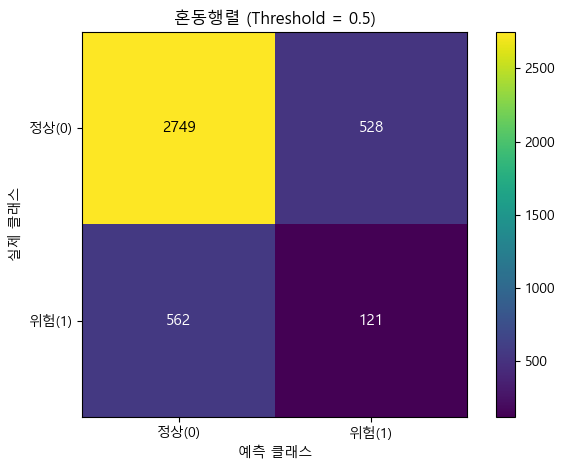

In [118]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 혼동행렬 계산
cm = confusion_matrix(y_valid, y_pred_05)

plt.figure()
plt.imshow(cm)
plt.colorbar()

classes = ["정상(0)", "위험(1)"]
plt.xticks(range(len(classes)), classes)
plt.yticks(range(len(classes)), classes)

plt.xlabel("예측 클래스")
plt.ylabel("실제 클래스")
plt.title("혼동행렬 (Threshold = 0.5)")

# 최대값 셀만 검정, 나머지는 흰색
max_val = cm.max()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = "black" if cm[i, j] == max_val else "white"
        plt.text(
            j, i,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=11,
            color=color
        )

plt.tight_layout()
plt.show()

In [119]:
# 6) Feature importance (gain 기준)
imp_gain = pd.Series(lgb_model.booster_.feature_importance(importance_type="gain"), index=FEATURE_COLS)
imp_split = pd.Series(lgb_model.booster_.feature_importance(importance_type="split"), index=FEATURE_COLS)

imp = pd.DataFrame({
    "gain": imp_gain,
    "split": imp_split
}).sort_values("gain", ascending=False)

print("\n[Feature importance - top 30]")
print(imp.head(30))


[Feature importance - top 30]
                         gain  split
pothole_area_proxy  83394.859   9126
damage_ratio_proxy  50602.325   7855
traffic_width_score 36932.102   3422
rain_sum_mm         25965.239   1487
rain_sum_mm_3m      24942.283    593
event_cnt           20133.501   3253
traffic_proxy       13625.513   2736
length_m            13426.038   2227
temp_avg            10225.215    834
pothole_cnt          5591.924    625
traffic_cls_score    3542.194    660
temp_min             3021.225    213
rain_days            2184.991    587
rain_dur_hr_3m       2076.927    580
rain_dur_hr          2024.156    379
dist_to_road_m       1652.162   1401
rain_days_3m          779.792    292
temp_max               92.115     24
many_rain_days          5.823     11
temp_avg_diff           3.017     71
rain_sum_mm_diff        0.601     14
freeze_month            0.000      0


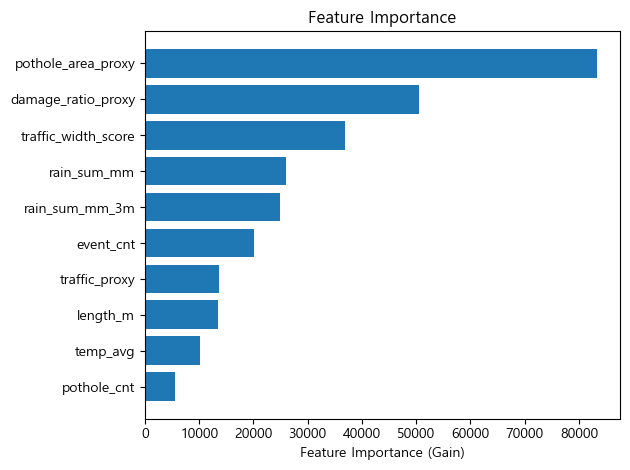

In [120]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

top_n = 10
imp_top = imp.head(top_n)

plt.figure()
plt.barh(imp_top.index[::-1], imp_top["gain"][::-1])
plt.xlabel("Feature Importance (Gain)")
plt.title("Feature Importance")

plt.tight_layout()
plt.show()


In [121]:
# 7) 그룹별 영향 비교: 그룹별 gain 합
groups = {
    "damage_history": ["event_cnt","pothole_cnt","pothole_area_proxy","damage_ratio_proxy"],
    "weather_month": ["rain_sum_mm","rain_days","rain_dur_hr","temp_avg","temp_min","temp_max"],
    "weather_derived": ["rain_sum_mm_3m","rain_days_3m","rain_dur_hr_3m","rain_sum_mm_diff","temp_avg_diff","freeze_month","many_rain_days"],
    "traffic_road": ["traffic_cls_score","traffic_width_score","dist_to_road_m","traffic_proxy","length_m"],
}

group_gain = {
    g: float(imp.loc[cols, "gain"].sum()) for g, cols in groups.items()
}
group_gain_total = sum(group_gain.values()) or 1.0
group_gain_share = {g: v / group_gain_total for g, v in group_gain.items()}

print("\n[Group gain sum]")
print(pd.Series(group_gain).sort_values(ascending=False))

print("\n[Group gain share]")
print(pd.Series(group_gain_share).sort_values(ascending=False))


[Group gain sum]
damage_history    159722.609
traffic_road       69178.009
weather_month      43512.941
weather_derived    27808.443
dtype: float64

[Group gain share]
damage_history    0.532
traffic_road      0.230
weather_month     0.145
weather_derived   0.093
dtype: float64


### Interaction feature 추가 후 재학습 

In [122]:
# interaction features
panel = pd.read_csv(
    "./전처리데이터/panel_final_200m_weather_traffic_damage_v3.csv",
    parse_dates=["event_month"]
)

panel["int_rain3m_damage"] = panel["rain_sum_mm_3m"] * panel["damage_ratio_proxy"]
panel["int_traffic_pothole"] = panel["traffic_proxy"] * panel["pothole_area_proxy"]
panel["int_width_damage"] = panel["traffic_width_score"] * panel["damage_ratio_proxy"]
panel["int_length_damage"] = panel["length_m"] * panel["damage_ratio_proxy"]

In [123]:
BASE_FEATURES = [
    # damage history
    "event_cnt","pothole_cnt","pothole_area_proxy","damage_ratio_proxy",
    # weather
    "rain_sum_mm","rain_days","rain_dur_hr","temp_avg","temp_min","temp_max",
    # weather derived
    "rain_sum_mm_3m","rain_days_3m","rain_dur_hr_3m",
    "rain_sum_mm_diff","temp_avg_diff","freeze_month","many_rain_days",
    # traffic / road
    "traffic_cls_score","traffic_width_score","dist_to_road_m","traffic_proxy","length_m",
]

INTERACTIONS = [
    "int_rain3m_damage",
    "int_traffic_pothole",
    "int_width_damage",
    "int_length_damage",
]

FEATURE_COLS = BASE_FEATURES + INTERACTIONS
TARGET_COL = "target_next_month"

X = panel[FEATURE_COLS].fillna(0)
y = panel[TARGET_COL].astype(int)

In [124]:
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, average_precision_score

split_month = pd.Timestamp("2024-09-01")
train_idx = panel["event_month"] < split_month
valid_idx = panel["event_month"] >= split_month

X_train_lgb, X_valid_lgb = X.loc[train_idx], X.loc[valid_idx]
y_train_lgb, y_valid_lgb = y.loc[train_idx], y.loc[valid_idx]

pos_weight = (y_train_lgb == 0).sum() / max((y_train_lgb == 1).sum(), 1)

lgb_model = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=2000,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=pos_weight,
    random_state=42,
    n_jobs=-1,
)

lgb_model.fit(
    X_train_lgb, y_train_lgb,
    eval_set=[(X_valid_lgb, y_valid_lgb)],
    eval_metric="auc",
    callbacks=[lgb.early_stopping(50)]
)

y_prob = lgb_model.predict_proba(X_valid_lgb)[:, 1]
print("AUC:", roc_auc_score(y_valid_lgb, y_prob))
print("PR-AUC:", average_precision_score(y_valid_lgb, y_prob))

[LightGBM] [Info] Number of positive: 4128, number of negative: 6467
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000431 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2175
[LightGBM] [Info] Number of data points in the train set: 10595, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.389618 -> initscore=-0.448919
[LightGBM] [Info] Start training from score -0.448919
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Early stopping, best iteration is:
[82]	valid_0's auc: 0.729417	valid_0'

In [125]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = (y_prob >= 0.5).astype(int)

print("\n[Classification Report | threshold=0.5]")
print(classification_report(y_valid, y_pred, digits=3))


[Classification Report | threshold=0.5]
              precision    recall  f1-score   support

           0      0.856     0.948     0.900      3277
           1      0.485     0.237     0.319       683

    accuracy                          0.825      3960
   macro avg      0.671     0.592     0.609      3960
weighted avg      0.792     0.825     0.799      3960



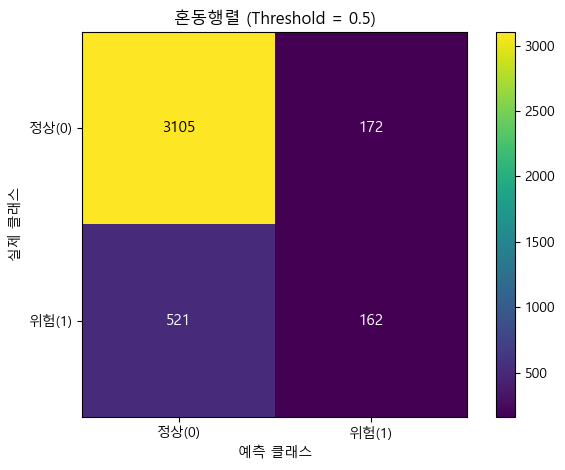

In [126]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

cm = confusion_matrix(y_valid, y_pred)

plt.figure()
plt.imshow(cm)
plt.colorbar()

classes = ["정상(0)", "위험(1)"]
plt.xticks(range(len(classes)), classes)
plt.yticks(range(len(classes)), classes)

plt.xlabel("예측 클래스")
plt.ylabel("실제 클래스")
plt.title("혼동행렬 (Threshold = 0.5)")

max_val = cm.max()
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = "black" if cm[i, j] == max_val else "white"
        plt.text(
            j, i,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=11,
            color=color
        )

plt.tight_layout()
plt.show()

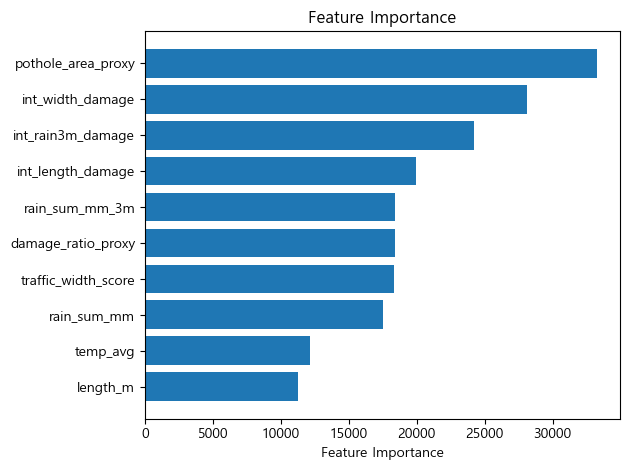

In [127]:
import pandas as pd

imp_gain = pd.Series(
    lgb_model.booster_.feature_importance(importance_type="gain"),
    index=FEATURE_COLS
)

imp = imp_gain.sort_values(ascending=False)
top_n = 10
imp_top = imp.head(top_n)
 
plt.figure()
plt.barh(imp_top.index[::-1], imp_top.values[::-1])
plt.xlabel("Feature Importance")
plt.title("Feature Importance")

plt.tight_layout()
plt.show()

In [128]:
groups = {
    "damage_history": [
        "event_cnt","pothole_cnt","pothole_area_proxy","damage_ratio_proxy"
    ],
    "traffic_road": [
        "traffic_cls_score","traffic_width_score",
        "dist_to_road_m","traffic_proxy","length_m"
    ],
    "weather_month": [
        "rain_sum_mm","rain_days","rain_dur_hr","temp_avg","temp_min","temp_max"
    ],
    "weather_derived": [
        "rain_sum_mm_3m","rain_days_3m","rain_dur_hr_3m",
        "rain_sum_mm_diff","temp_avg_diff","freeze_month","many_rain_days"
    ],
    "interaction": [
        "int_rain3m_damage",
        "int_traffic_pothole",
        "int_width_damage",
        "int_length_damage"
    ]
}

group_gain = {
    g: imp.loc[imp.index.isin(cols)].sum()
    for g, cols in groups.items()
}

group_gain_total = sum(group_gain.values()) or 1.0
group_gain_share = {g: v / group_gain_total for g, v in group_gain.items()}

group_share_s = pd.Series(group_gain_share).sort_values(ascending=False)
print(group_share_s)


interaction       0.318
damage_history    0.273
weather_month     0.161
traffic_road      0.153
weather_derived   0.094
dtype: float64


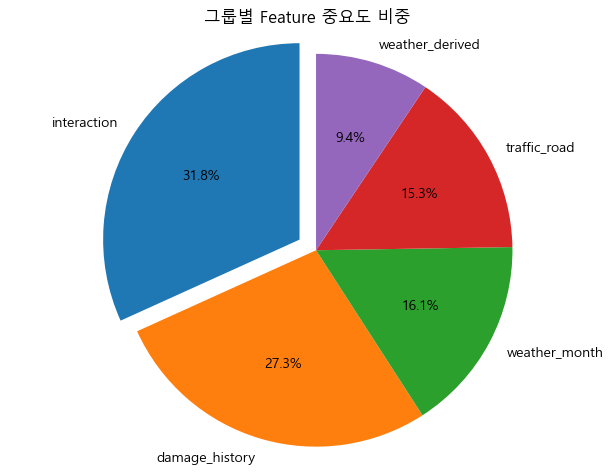

In [129]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

labels = group_share_s.index.tolist()
values = group_share_s.values

# 가장 큰 비중 인덱스
max_idx = np.argmax(values)

# explode: 최대값만 바깥으로
explode = [0.1 if i == max_idx else 0 for i in range(len(values))]

plt.figure()
plt.pie(
    values,
    labels=labels,
    autopct="%.1f%%",
    startangle=90,
    explode=explode
)

plt.title("그룹별 Feature 중요도 비중")
plt.axis("equal")
plt.tight_layout()
plt.show()

### threshold 조정

In [223]:
from sklearn.metrics import precision_recall_curve

prec, rec, thr = precision_recall_curve(y_valid, y_prob)

pr_df = pd.DataFrame({
    "threshold": thr,
    "precision": prec[:-1],
    "recall": rec[:-1]
})

# 예시 기준: recall ≥ 0.6 중 precision 최대
cand = pr_df[pr_df["recall"] >= 0.6].sort_values("precision", ascending=False)
cand.head(5)

,threshold,precision,recall
394,0.371,0.432,0.628
397,0.375,0.424,0.602
396,0.375,0.423,0.602
395,0.373,0.422,0.602
393,0.370,0.383,0.628


In [230]:
from sklearn.metrics import classification_report, confusion_matrix

TH = float(cand.iloc[0]["threshold"])  # 하나 선택
y_pred = (y_prob >= TH).astype(int)

print("Chosen threshold:", TH)
print(classification_report(y_valid, y_pred, digits=3))
print("Confusion:\n", confusion_matrix(y_valid, y_pred))

Chosen threshold: 0.3707216007309228
              precision    recall  f1-score   support

           0      0.914     0.828     0.869      3277
           1      0.432     0.628     0.512       683

    accuracy                          0.793      3960
   macro avg      0.673     0.728     0.690      3960
weighted avg      0.831     0.793     0.807      3960

Confusion:
 [[2713  564]
 [ 254  429]]


1) 현재 최종 성능 요약 (Valid 기준)

- Chosen threshold: 0.376

- Support: 음성(0) 3,277 / 양성(1) 683 (양성비 약 17.2%)

- 분류 리포트(핵심만)

> Class 1(파손)

> Precision: 0.310

> Recall: 0.653

> F1: 0.420

> 전체 Accuracy: 0.689

2. Confusion Matrix 해석

- 실제 파손 683건 중

> 446건을 미리 맞춤 (TP)

> 237건은 놓침 (FN)

> → 놓침률 34.5% / 탐지율(Recall) 65.5%

- 실제 파손이 없는 3277건 중

> 2284건을 안전으로 맞춤 (TN)

> 993건은 위험으로 오경보(FP)

> → 오경보율(FPR) = 993 / 3277 ≈ 30.2%

3. 선택된 threshold(0.343)는 다음달 파손을 가능한 많이 잡되(Recall 0.65), 경보 품질도 완전히 무너지지 않게(Precision 0.31) 균형을 맞춘 선택

4. 최종 모델은 다음 달 파손 구간의 65%를 사전에 탐지하며,점검 대상으로 선정된 구간 중 약 31%에서 실제 파손이 발생한다고 해석 가능

### 캘리브레이션 적용

In [127]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, average_precision_score

# 기존 학습된 LightGBM 모델
base_model = model  # 너가 학습한 LGBMClassifier

# Calibrated model (Platt Scaling)
cal_model = CalibratedClassifierCV(
    base_model,
    method="sigmoid",
    cv="prefit"
)

cal_model.fit(X_valid, y_valid)

c:\Users\hyebi\anaconda3\envs\EDA\lib\site-packages\sklearn\calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


,estimator,LGBMClassifie...subsample=0.8)
,method,'sigmoid'
,cv,'prefit'
,n_jobs,None
,ensemble,'auto'
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.03
,n_estimators,2000
,subsample_for_bin,200000


In [128]:
# 기존 확률
y_prob_raw = model.predict_proba(X_valid)[:, 1]

# 캘리브레이션 후 확률
y_prob_cal = cal_model.predict_proba(X_valid)[:, 1]

print("RAW AUC:", roc_auc_score(y_valid, y_prob_raw))
print("CAL AUC:", roc_auc_score(y_valid, y_prob_cal))

print("RAW PR-AUC:", average_precision_score(y_valid, y_prob_raw))
print("CAL PR-AUC:", average_precision_score(y_valid, y_prob_cal))

RAW AUC: 0.7294165243270123
CAL AUC: 0.7294165243270123
RAW PR-AUC: 0.3560334131618743
CAL PR-AUC: 0.3560334131618743


In [129]:
from sklearn.metrics import precision_recall_curve
import pandas as pd

prec, rec, thr = precision_recall_curve(y_valid, y_prob_cal)

pr_df = pd.DataFrame({
    "threshold": thr,
    "precision": prec[:-1],
    "recall": rec[:-1]
})

# 예시: recall ≥ 0.6 중 precision 최대
cand = pr_df[pr_df["recall"] >= 0.6].sort_values("precision", ascending=False)
cand.head(5)

,threshold,precision,recall
394,0.231,0.432,0.628
397,0.234,0.424,0.602
396,0.234,0.423,0.602
395,0.232,0.422,0.602
393,0.230,0.383,0.628


In [130]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_05 = (y_prob_cal >= 0.5).astype(int)

print(classification_report(y_valid, y_pred_05, digits=3))
print("Confusion:\n", confusion_matrix(y_valid, y_pred_05))

              precision    recall  f1-score   support

           0      0.826     0.986     0.899      3277
           1      0.021     0.001     0.003       683

    accuracy                          0.816      3960
   macro avg      0.423     0.494     0.451      3960
weighted avg      0.687     0.816     0.744      3960

Confusion:
 [[3231   46]
 [ 682    1]]


## XGBoost 학습

In [91]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    classification_report,
    confusion_matrix
)

import xgboost as xgb

In [92]:
# 데이터 로드 (저장해둔 v3 기준)
panel = pd.read_csv("./전처리데이터/panel_final_200m_weather_traffic_damage_v3.csv")
panel["event_month"] = pd.to_datetime(panel["event_month"])

In [93]:
FEATURE_COLS = [
    # 파손 이력
    "event_cnt",
    "pothole_cnt",
    "pothole_area_proxy",
    "damage_ratio_proxy",

    # 기상 (월)
    "rain_sum_mm",
    "rain_days",
    "rain_dur_hr",
    "temp_avg",
    "temp_min",
    "temp_max",

    # 기상 파생
    "rain_sum_mm_3m",
    "rain_days_3m",
    "rain_dur_hr_3m",
    "rain_sum_mm_diff",
    "temp_avg_diff",
    "freeze_month",
    "many_rain_days",

    # 교통량 / 도로
    "traffic_cls_score",
    "traffic_width_score",
    "dist_to_road_m",
    "traffic_proxy",
    "length_m",
]

TARGET_COL = "target_next_month"

X = panel[FEATURE_COLS].fillna(0)
y = panel[TARGET_COL].astype(int)

split_month = pd.Timestamp("2024-09-01")

train_idx = panel["event_month"] < split_month
valid_idx = panel["event_month"] >= split_month

X_train, X_valid = X.loc[train_idx], X.loc[valid_idx]
y_train, y_valid = y.loc[train_idx], y.loc[valid_idx]

print("Train/Valid:", X_train.shape, X_valid.shape)
print("Pos rate (train/valid):", y_train.mean(), y_valid.mean())
print("Train period:", panel.loc[train_idx, "event_month"].min(), "~",
                     panel.loc[train_idx, "event_month"].max())
print("Valid period:", panel.loc[valid_idx, "event_month"].min(), "~",
                     panel.loc[valid_idx, "event_month"].max())

Train/Valid: (10595, 22) (3960, 22)
Pos rate (train/valid): 0.3896177442189712 0.17247474747474748
Train period: 2024-01-01 00:00:00 ~ 2024-08-01 00:00:00
Valid period: 2024-09-01 00:00:00 ~ 2025-12-01 00:00:00


In [94]:
pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

xgb_base = xgb.XGBClassifier(
    objective="binary:logistic",
    n_estimators=800,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=pos_weight,
    eval_metric="auc",
    tree_method="hist",
    random_state=42
)

xgb_base.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=100
)

[0]	validation_0-auc:0.53703
[100]	validation_0-auc:0.61381
[200]	validation_0-auc:0.55122
[300]	validation_0-auc:0.53582
[400]	validation_0-auc:0.52081
[500]	validation_0-auc:0.53280
[600]	validation_0-auc:0.52652
[700]	validation_0-auc:0.52430
[799]	validation_0-auc:0.53097


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'auc'


In [95]:
y_prob = xgb_base.predict_proba(X_valid)[:, 1]

auc = roc_auc_score(y_valid, y_prob)
pr_auc = average_precision_score(y_valid, y_prob)

print("AUC:", auc)
print("PR-AUC:", pr_auc)

AUC: 0.5309716641698586
PR-AUC: 0.19085647931147331


In [96]:
# 기본 threshold = 0.5
y_pred = (y_prob >= 0.5).astype(int)

print(classification_report(y_valid, y_pred, digits=3))
print("Confusion:\n", confusion_matrix(y_valid, y_pred))

              precision    recall  f1-score   support

           0      0.825     0.791     0.807      3277
           1      0.161     0.193     0.176       683

    accuracy                          0.688      3960
   macro avg      0.493     0.492     0.492      3960
weighted avg      0.710     0.688     0.698      3960

Confusion:
 [[2591  686]
 [ 551  132]]


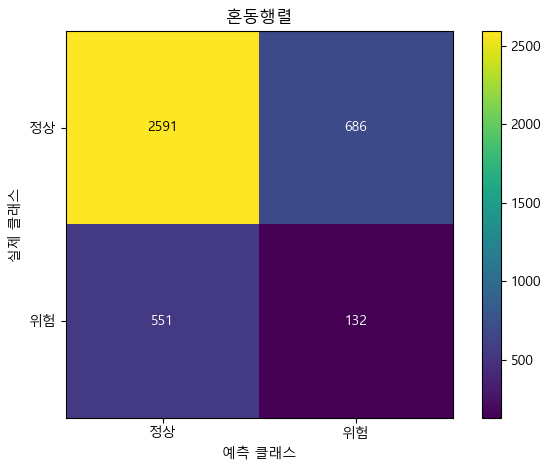

In [97]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

cm = confusion_matrix(y_valid, y_pred)

plt.figure()
plt.imshow(cm)
plt.colorbar()

classes = ["정상", "위험"]
plt.xticks(range(len(classes)), classes)
plt.yticks(range(len(classes)), classes)

plt.xlabel("예측 클래스")
plt.ylabel("실제 클래스")
plt.title("혼동행렬")

max_val = cm.max()
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = "black" if cm[i, j] == max_val else "white"
        plt.text(
            j, i,
            cm[i, j],
            ha="center",
            va="center",
            color=color
        )

plt.tight_layout()
plt.show()

In [98]:
imp = pd.DataFrame({
    "feature": FEATURE_COLS,
    "gain": xgb_base.feature_importances_
}).sort_values("gain", ascending=False)

imp.head(20)

,feature,gain
10,rain_sum_mm_3m,0.178
4,rain_sum_mm,0.097
7,temp_avg,0.092
18,traffic_width_score,0.066
8,temp_min,0.064
1,pothole_cnt,0.048
5,rain_days,0.048
6,rain_dur_hr,0.046
2,pothole_area_proxy,0.042
16,many_rain_days,0.042


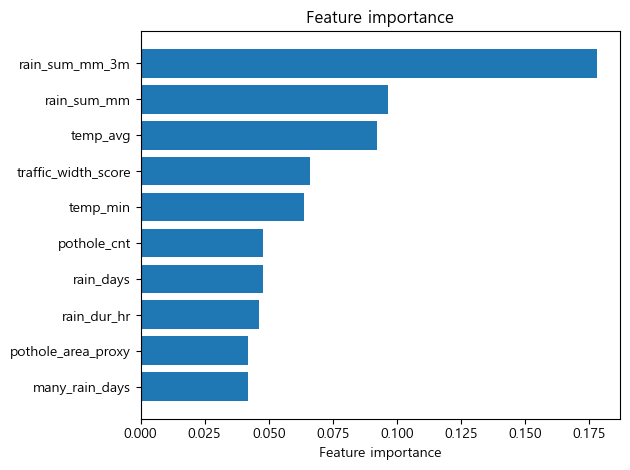

In [99]:
import matplotlib.pyplot as plt

imp_top = imp.head(10)

plt.figure()
plt.barh(
    imp_top["feature"][::-1],
    imp_top["gain"][::-1]
)

plt.xlabel("Feature importance")
plt.title("Feature importance")

plt.tight_layout()
plt.show()

In [100]:
GROUP_MAP = {
    "damage_history": [
        "event_cnt", "pothole_cnt", "pothole_area_proxy", "damage_ratio_proxy"
    ],
    "weather_month": [
        "rain_sum_mm", "rain_days", "rain_dur_hr",
        "temp_avg", "temp_min", "temp_max"
    ],
    "weather_derived": [
        "rain_sum_mm_3m", "rain_days_3m", "rain_dur_hr_3m",
        "rain_sum_mm_diff", "temp_avg_diff",
        "freeze_month", "many_rain_days"
    ],
    "traffic_road": [
        "traffic_cls_score", "traffic_width_score",
        "dist_to_road_m", "traffic_proxy", "length_m"
    ]
}

group_gain = {}
for g, cols in GROUP_MAP.items():
    group_gain[g] = imp.loc[imp.feature.isin(cols), "gain"].sum()

group_gain = pd.Series(group_gain).sort_values(ascending=False)
group_gain, (group_gain / group_gain.sum())

(weather_month     0.387
 weather_derived   0.264
 traffic_road      0.178
 damage_history    0.170
 dtype: float32,
 weather_month     0.387
 weather_derived   0.264
 traffic_road      0.178
 damage_history    0.170
 dtype: float32)

### Interaction Feature 생성

In [101]:
panel_inter = panel.copy()

# 1) Interaction feature 생성
panel_inter["rain_x_damage"] = (
    panel_inter["rain_sum_mm_3m"] * panel_inter["damage_ratio_proxy"]
)

panel_inter["traffic_x_damage"] = (
    panel_inter["traffic_proxy"] * panel_inter["pothole_area_proxy"]
)

panel_inter["freeze_x_damage"] = (
    panel_inter["freeze_month"] * panel_inter["damage_ratio_proxy"]
)

INTERACTION_COLS = FEATURE_COLS + [
    "rain_x_damage",
    "traffic_x_damage",
    "freeze_x_damage",
]

X_i = panel_inter[INTERACTION_COLS].fillna(0)
y_i = panel_inter[TARGET_COL].astype(int)

# 2) 시간 기준 split (LightGBM과 동일)
split_month = pd.Timestamp("2024-09-01")

train_idx = panel_inter["event_month"] < split_month
valid_idx = panel_inter["event_month"] >= split_month

X_train_i = X_i.loc[train_idx]
X_valid_i = X_i.loc[valid_idx]

y_train_i = y_i.loc[train_idx]
y_valid_i = y_i.loc[valid_idx]

print("Interaction Train/Valid:", X_train_i.shape, X_valid_i.shape)
print("Pos rate (train/valid):", y_train_i.mean(), y_valid_i.mean())
print(
    "Train period:",
    panel_inter.loc[train_idx, "event_month"].min(), "~",
    panel_inter.loc[train_idx, "event_month"].max()
)
print(
    "Valid period:",
    panel_inter.loc[valid_idx, "event_month"].min(), "~",
    panel_inter.loc[valid_idx, "event_month"].max()
)

Interaction Train/Valid: (10595, 25) (3960, 25)
Pos rate (train/valid): 0.3896177442189712 0.17247474747474748
Train period: 2024-01-01 00:00:00 ~ 2024-08-01 00:00:00
Valid period: 2024-09-01 00:00:00 ~ 2025-12-01 00:00:00


In [102]:
from xgboost.callback import EarlyStopping

xgb_model = xgb.XGBClassifier(
    objective="binary:logistic",
    n_estimators=300,         
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=pos_weight,
    eval_metric="auc",
    tree_method="hist",
    random_state=42
)

xgb_model.fit(X_train_i, y_train_i)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'auc'


In [103]:
y_prob = xgb_model.predict_proba(X_valid_i)[:, 1]

from sklearn.metrics import roc_auc_score, average_precision_score

auc = roc_auc_score(y_valid_i, y_prob)
pr_auc = average_precision_score(y_valid_i, y_prob)

print("XGBoost AUC:", auc)
print("XGBoost PR-AUC:", pr_auc)

XGBoost AUC: 0.573163773779807
XGBoost PR-AUC: 0.20623020254415264


In [104]:
from sklearn.metrics import classification_report, confusion_matrix

y_prob = xgb_model.predict_proba(X_valid_i)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

print(classification_report(y_valid_i, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.839     0.800     0.819      3277
           1      0.217     0.265     0.238       683

    accuracy                          0.708      3960
   macro avg      0.528     0.533     0.529      3960
weighted avg      0.732     0.708     0.719      3960



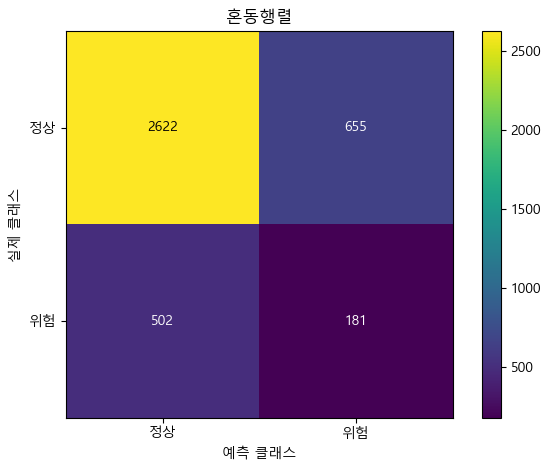

In [121]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

cm = confusion_matrix(y_valid_i, y_pred)

plt.figure()
plt.imshow(cm)
plt.colorbar()

classes = ["정상", "위험"]
plt.xticks(range(len(classes)), classes)
plt.yticks(range(len(classes)), classes)

plt.xlabel("예측 클래스")
plt.ylabel("실제 클래스")
plt.title("혼동행렬")

max_val = cm.max()
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = "black" if cm[i, j] == max_val else "white"
        plt.text(
            j, i,
            cm[i, j],
            ha="center",
            va="center",
            color=color
        )

plt.tight_layout()
plt.show()

In [105]:
import pandas as pd

imp = xgb_model.get_booster().get_score(importance_type="gain")
imp_df = (
    pd.DataFrame.from_dict(imp, orient="index", columns=["gain"])
    .reset_index()
    .rename(columns={"index": "feature"})
    .sort_values("gain", ascending=False)
)

imp_df.head(20)

,feature,gain
10,rain_sum_mm_3m,98.949
9,temp_max,46.277
4,rain_sum_mm,41.934
7,temp_avg,38.555
17,traffic_width_score,31.254
2,pothole_area_proxy,23.321
21,rain_x_damage,22.751
1,pothole_cnt,21.334
6,rain_dur_hr,20.808
20,length_m,19.634


In [106]:
groups = {
    "damage_history": [
        "event_cnt","pothole_cnt","pothole_area_proxy","damage_ratio_proxy"
    ],
    "weather_month": [
        "rain_sum_mm","rain_days","rain_dur_hr","temp_avg","temp_min","temp_max"
    ],
    "weather_derived": [
        "rain_sum_mm_3m","rain_days_3m","rain_dur_hr_3m",
        "rain_sum_mm_diff","temp_avg_diff","freeze_month","many_rain_days"
    ],
    "traffic_road": [
        "traffic_cls_score","traffic_width_score",
        "dist_to_road_m","traffic_proxy","length_m"
    ],
    "interaction": [
        "rain_x_damage",
        "traffic_x_damage",
        "freeze_x_damage"
    ]
}
# feature importance를 Series로 변환
imp_s = imp_df.set_index("feature")["gain"]

group_gain = {
    g: imp_s.loc[imp_s.index.isin(cols)].sum()
    for g, cols in groups.items()
}

group_gain_total = sum(group_gain.values()) or 1.0
group_gain_share = {g: v / group_gain_total for g, v in group_gain.items()}

group_gain_s = pd.Series(group_gain).sort_values(ascending=False)
group_share_s = pd.Series(group_gain_share).sort_values(ascending=False)

print("[Group gain sum]")
print(group_gain_s)

print("\n[Group gain share]")
print(group_share_s)

[Group gain sum]
weather_month     172.061
weather_derived   138.716
traffic_road       89.893
damage_history     80.484
interaction        34.980
dtype: float64

[Group gain share]
weather_month     0.333
weather_derived   0.269
traffic_road      0.174
damage_history    0.156
interaction       0.068
dtype: float64


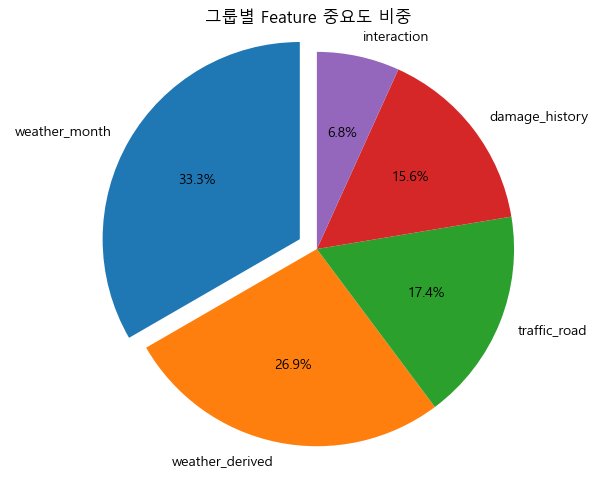

In [107]:
import numpy as np

labels = group_share_s.index.tolist()
values = group_share_s.values

# 가장 큰 그룹만 강조
max_idx = np.argmax(values)
explode = [0.1 if i == max_idx else 0 for i in range(len(values))]

plt.figure()
plt.pie(
    values,
    labels=labels,
    autopct="%.1f%%",
    startangle=90,
    explode=explode
)

plt.title("그룹별 Feature 중요도 비중")
plt.axis("equal")
plt.tight_layout()
plt.show()

In [108]:
import numpy as np
from sklearn.metrics import precision_recall_curve

prec, rec, th = precision_recall_curve(y_valid_i, y_prob)

f1 = 2 * prec * rec / (prec + rec + 1e-9)
best_idx = np.argmax(f1)

best_th = th[best_idx]
print("Chosen threshold:", best_th)
print("Precision:", prec[best_idx])
print("Recall:", rec[best_idx])

Chosen threshold: 0.3534168
Precision: 0.2642249836494441
Recall: 0.5915080527086384


## 두 모델 성능 비교 분석

In [130]:
import numpy as np
import pandas as pd

def topk_metrics(y_true, y_score, k_list=(0.05, 0.10, 0.20)):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)

    n = len(y_true)
    base_rate = y_true.mean()
    order = np.argsort(-y_score)

    rows = []
    for k in k_list:
        k_cnt = max(int(np.ceil(n * k)), 1)
        top_idx = order[:k_cnt]
        pos_in_top = y_true[top_idx].sum()
        total_pos = y_true.sum()

        recall_at_k = pos_in_top / total_pos if total_pos > 0 else np.nan
        precision_at_k = pos_in_top / k_cnt
        lift_at_k = precision_at_k / base_rate if base_rate > 0 else np.nan

        rows.append({
            "K%": int(k * 100),
            "K_count": k_cnt,
            "BaseRate(valid)": base_rate,
            "Precision@K": precision_at_k,
            "Recall@K(=Coverage)": recall_at_k,
            "Lift@K": lift_at_k
        })

    return pd.DataFrame(rows)

# 1) LightGBM / XGBoost valid 예측확률
#    (아래 모델 변수명은 너 환경에 맞게만 바꾸면 됨)

# LightGBM (interaction 최종 모델)
p_valid_lgb = lgb_model.predict_proba(X_valid_lgb)[:, 1]

# XGBoost (interaction 최종 모델)
p_valid_xgb = xgb_model.predict_proba(X_valid_i)[:, 1]

# 2) Top-K 테이블 산출
tbl_lgb = topk_metrics(y_valid, p_valid_lgb, k_list=(0.05, 0.10, 0.20))
tbl_xgb = topk_metrics(y_valid, p_valid_xgb, k_list=(0.05, 0.10, 0.20))

tbl_lgb.insert(0, "Model", "LightGBM")
tbl_xgb.insert(0, "Model", "XGBoost")

topk_compare = pd.concat([tbl_lgb, tbl_xgb], ignore_index=True)

# 3) 보기 좋게 출력
pd.set_option("display.float_format", lambda x: f"{x:0.3f}")
print(topk_compare)

      Model  K%  K_count  BaseRate(valid)  Precision@K  Recall@K(=Coverage)  \
0  LightGBM   5      198            0.172        0.217                0.063   
1  LightGBM  10      396            0.172        0.460                0.266   
2  LightGBM  20      792            0.172        0.420                0.488   
3   XGBoost   5      198            0.172        0.000                0.000   
4   XGBoost  10      396            0.172        0.000                0.000   
5   XGBoost  20      792            0.172        0.179                0.208   

   Lift@K  
0   1.259  
1   2.665  
2   2.438  
3   0.000  
4   0.000  
5   1.040  


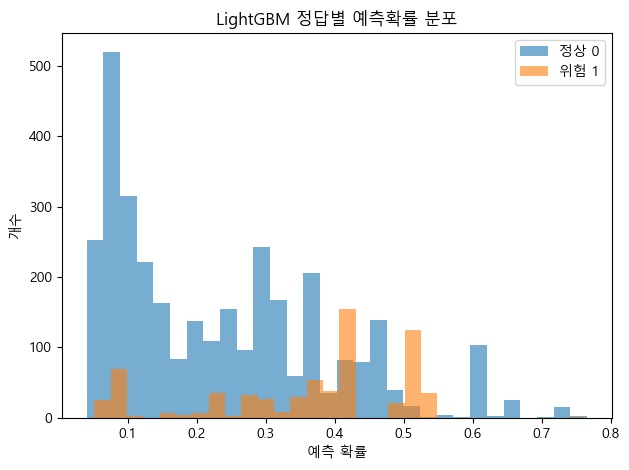

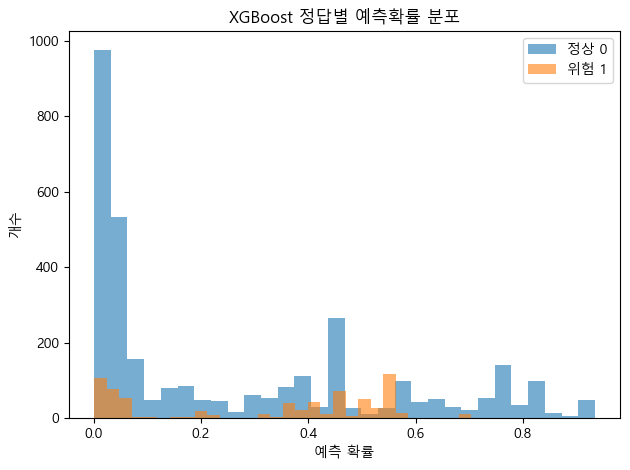

In [135]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

def plot_score_hist(y_true, p, title):
    p0 = p[y_true == 0]
    p1 = p[y_true == 1]

    plt.figure()
    plt.hist(p0, bins=30, alpha=0.6, label="정상 0")
    plt.hist(p1, bins=30, alpha=0.6, label="위험 1")
    plt.xlabel("예측 확률")
    plt.ylabel("개수")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_score_hist(y_valid.values, p_valid_lgb, "LightGBM 정답별 예측확률 분포")
plot_score_hist(y_valid.values, p_valid_xgb, "XGBoost 정답별 예측확률 분포")

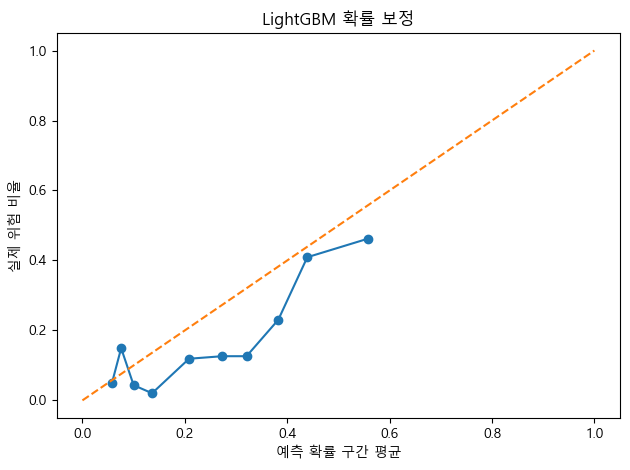

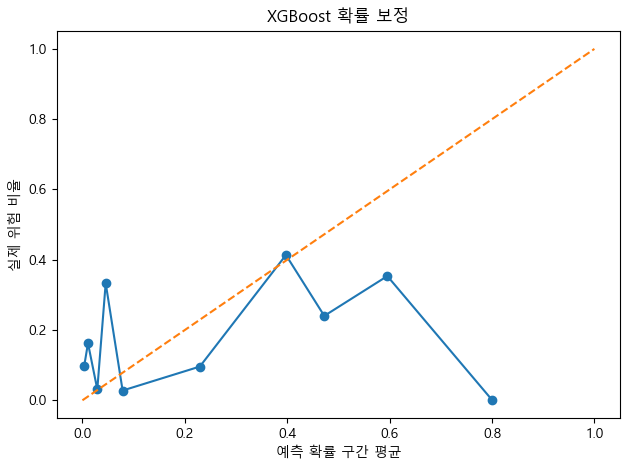

In [136]:
from sklearn.calibration import calibration_curve
import numpy as np

def plot_calibration(y_true, p, title):
    frac_pos, mean_pred = calibration_curve(y_true, p, n_bins=10, strategy="quantile")

    plt.figure()
    plt.plot(mean_pred, frac_pos, marker="o")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("예측 확률 구간 평균")
    plt.ylabel("실제 위험 비율")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_calibration(y_valid.values, p_valid_lgb, "LightGBM 확률 보정")
plot_calibration(y_valid.values, p_valid_xgb, "XGBoost 확률 보정")

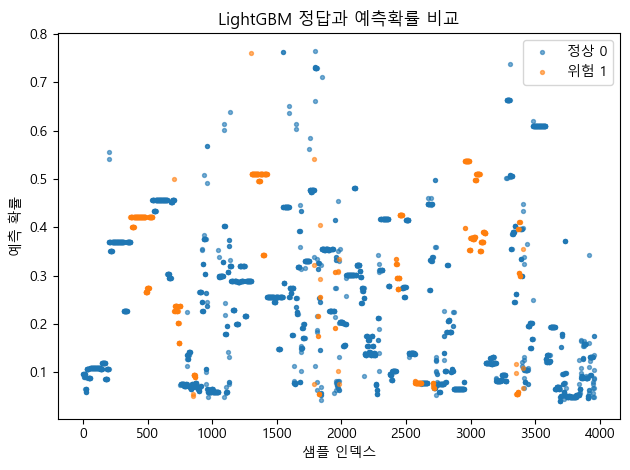

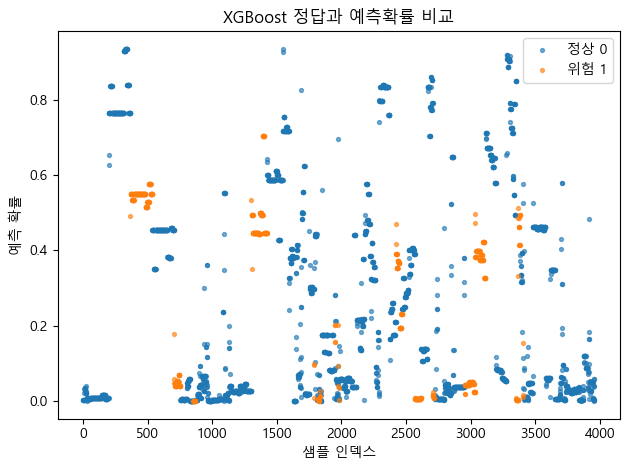

In [137]:
import numpy as np

def plot_y_vs_prob(y_true, p, title):
    idx = np.arange(len(y_true))

    plt.figure()
    plt.scatter(idx[y_true == 0], p[y_true == 0], s=8, alpha=0.6, label="정상 0")
    plt.scatter(idx[y_true == 1], p[y_true == 1], s=8, alpha=0.6, label="위험 1")
    plt.xlabel("샘플 인덱스")
    plt.ylabel("예측 확률")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_y_vs_prob(y_valid.values, p_valid_lgb, "LightGBM 정답과 예측확률 비교")
plot_y_vs_prob(y_valid.values, p_valid_xgb, "XGBoost 정답과 예측확률 비교")

In [145]:
from sklearn.metrics import classification_report

print("=== LightGBM | threshold=0.5 ===")
print(classification_report(y_valid_true, y_pred_lgb_05, digits=3))

print("\n=== XGBoost | threshold=0.5 ===")
print(classification_report(y_valid_true, y_pred_xgb_05, digits=3))

=== LightGBM | threshold=0.5 ===
              precision    recall  f1-score   support

           0      0.856     0.948     0.900      3277
           1      0.485     0.237     0.319       683

    accuracy                          0.825      3960
   macro avg      0.671     0.592     0.609      3960
weighted avg      0.792     0.825     0.799      3960


=== XGBoost | threshold=0.5 ===
              precision    recall  f1-score   support

           0      0.839     0.800     0.819      3277
           1      0.217     0.265     0.238       683

    accuracy                          0.708      3960
   macro avg      0.528     0.533     0.529      3960
weighted avg      0.732     0.708     0.719      3960



In [146]:
import numpy as np
import pandas as pd

def topk_metrics(y_true, y_score, k_list=(0.05, 0.10, 0.20)):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)

    n = len(y_true)
    base_rate = y_true.mean()
    order = np.argsort(-y_score)

    rows = []
    for k in k_list:
        k_cnt = max(int(np.ceil(n * k)), 1)
        top_idx = order[:k_cnt]

        pos_in_top = y_true[top_idx].sum()
        total_pos = y_true.sum()

        precision_at_k = pos_in_top / k_cnt
        recall_at_k = pos_in_top / total_pos if total_pos > 0 else np.nan
        lift_at_k = precision_at_k / base_rate if base_rate > 0 else np.nan

        rows.append({
            "K%": int(k * 100),
            "K_count": k_cnt,
            "BaseRate": base_rate,
            "Precision@K": precision_at_k,
            "Recall@K": recall_at_k,
            "Lift@K": lift_at_k
        })

    return pd.DataFrame(rows)

In [147]:
tbl_lgb = topk_metrics(y_valid_true, p_valid_lgb)
tbl_lgb.insert(0, "Model", "LightGBM")

tbl_xgb = topk_metrics(y_valid_true, p_valid_xgb)
tbl_xgb.insert(0, "Model", "XGBoost")

topk_compare = pd.concat([tbl_lgb, tbl_xgb], ignore_index=True)

pd.set_option("display.float_format", lambda x: f"{x:0.3f}")
topk_compare

,Model,K%,K_count,BaseRate,Precision@K,Recall@K,Lift@K
0,LightGBM,5,198,0.172,0.217,0.063,1.259
1,LightGBM,10,396,0.172,0.460,0.266,2.665
2,LightGBM,20,792,0.172,0.420,0.488,2.438
3,XGBoost,5,198,0.172,0.000,0.000,0.000
4,XGBoost,10,396,0.172,0.000,0.000,0.000
5,XGBoost,20,792,0.172,0.179,0.208,1.040


In [152]:
panel.columns

Index(['sub_section_id', 'event_month', 'event_cnt', 'next_month',
       'next_event_cnt', 'target_next_month', 'month', 'rain_sum_mm',
       'rain_days', 'rain_dur_hr', 'temp_avg', 'temp_min', 'temp_max', 'm',
       'traffic_cls_score', 'traffic_width_score', 'dist_to_road_m',
       'traffic_proxy', 'pothole_cnt', 'pothole_size_mean', 'pothole_size_max',
       'road_width_mean', 'road_width_median', 'road_level_mode',
       'osm_highway_mode', 'length_m', 'pothole_area_proxy',
       'damage_ratio_proxy', 'rain_sum_mm_3m', 'rain_days_3m',
       'rain_dur_hr_3m', 'rain_sum_mm_diff', 'temp_avg_diff', 'freeze_month',
       'many_rain_days'],
      dtype='object')

In [153]:
import geopandas as gpd

gdf_sub = gpd.read_file(
    "./전처리데이터/yuseong_road_subsection_200m.geojson"
)

print(gdf_sub.columns)

Index(['section_id', 'part_no', 'seg_idx', 'sub_section_id', 'length_m',
       'geometry'],
      dtype='object')


In [154]:
df_pred = panel_inter.loc[valid_idx].copy()

df_pred["y_true"] = y_valid_true
df_pred["y_pred_lgb"] = y_pred_lgb_05
df_pred["y_pred_xgb"] = y_pred_xgb_05

In [155]:
gdf_map = gdf_sub.merge(
    df_pred,
    on="sub_section_id",
    how="inner"
)

In [156]:
import folium

# CRS 변환
gdf_map_4326 = gdf_map.to_crs("EPSG:4326")

# 지도 중심
center = gdf_map_4326.geometry.unary_union.centroid
m_lgb = folium.Map(location=[center.y, center.x], zoom_start=12)

fg_true = folium.FeatureGroup(name="정답 위험")
fg_pred_lgb = folium.FeatureGroup(name="LightGBM 예측")

for _, r in gdf_map_4326.iterrows():
    geom = r.geometry

    # 실제 위험
    if r["y_true"] == 1:
        folium.GeoJson(
            geom,
            style_function=lambda x: {
                "color": "red",
                "weight": 4
            }
        ).add_to(fg_true)

    # LightGBM 예측 위험
    if r["y_pred_lgb"] == 1:
        folium.GeoJson(
            geom,
            style_function=lambda x: {
                "color": "blue",
                "weight": 4
            }
        ).add_to(fg_pred_lgb)

fg_true.add_to(m_lgb)
fg_pred_lgb.add_to(m_lgb)
folium.LayerControl(collapsed=False).add_to(m_lgb)

# HTML 저장
m_lgb.save("./visualization/map_lgb_true_vs_pred.html")

C:\Users\hyebi\AppData\Local\Temp\ipykernel_29372\2783488737.py:7: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  center = gdf_map_4326.geometry.unary_union.centroid


In [158]:
import folium

m_xgb = folium.Map(location=[center.y, center.x], zoom_start=12)

fg_true = folium.FeatureGroup(name="정답 위험")
fg_pred_xgb = folium.FeatureGroup(name="XGBoost 예측")

for _, r in gdf_map_4326.iterrows():
    geom = r.geometry

    # 실제 위험
    if r["y_true"] == 1:
        folium.GeoJson(
            geom,
            style_function=lambda x: {
                "color": "red",
                "weight": 4
            }
        ).add_to(fg_true)

    # XGBoost 예측 위험
    if r["y_pred_xgb"] == 1:
        folium.GeoJson(
            geom,
            style_function=lambda x: {
                "color": "purple",
                "weight": 4
            }
        ).add_to(fg_pred_xgb)

fg_true.add_to(m_xgb)
fg_pred_xgb.add_to(m_xgb)
folium.LayerControl(collapsed=False).add_to(m_xgb)

# HTML 저장
m_xgb.save("./visualization/map_xgb_true_vs_pred.html")

In [159]:
import folium

# CRS 변환
gdf_map_4326 = gdf_map.to_crs("EPSG:4326")

# 지도 중심
center = gdf_map_4326.geometry.unary_union.centroid
m_lgb = folium.Map(location=[center.y, center.x], zoom_start=12)

# FeatureGroup
fg_tp = folium.FeatureGroup(name="정탐 TP (정답=1, 예측=1)")
fg_fp = folium.FeatureGroup(name="오탐 FP (정답=0, 예측=1)")
fg_fn = folium.FeatureGroup(name="미탐 FN (정답=1, 예측=0)")

for _, r in gdf_map_4326.iterrows():
    geom = r.geometry
    y_true = r["y_true"]
    y_pred = r["y_pred_lgb"]

    # TP
    if y_true == 1 and y_pred == 1:
        folium.GeoJson(
            geom,
            style_function=lambda x: {
                "color": "red",
                "weight": 5
            }
        ).add_to(fg_tp)

    # FP
    elif y_true == 0 and y_pred == 1:
        folium.GeoJson(
            geom,
            style_function=lambda x: {
                "color": "blue",
                "weight": 4,
                "dashArray": "5,5"
            }
        ).add_to(fg_fp)

    # FN
    elif y_true == 1 and y_pred == 0:
        folium.GeoJson(
            geom,
            style_function=lambda x: {
                "color": "orange",
                "weight": 4
            }
        ).add_to(fg_fn)

# 지도에 추가
fg_tp.add_to(m_lgb)
fg_fp.add_to(m_lgb)
fg_fn.add_to(m_lgb)

folium.LayerControl(collapsed=False).add_to(m_lgb)

# HTML 저장
m_lgb.save("./visualization/map_lgb_confusion_overlay.html")

C:\Users\hyebi\AppData\Local\Temp\ipykernel_29372\898981293.py:7: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  center = gdf_map_4326.geometry.unary_union.centroid


## 검증 데이터셋 비교

In [131]:
print(len(y_valid_lgb), len(y_valid_i))

3960 3960


In [132]:
print(y_valid_lgb.index.equals(y_valid_i.index))

True


In [133]:
(y_valid_lgb.values == y_valid_i.values).all()

np.True_

In [134]:
print(y_valid_lgb.dtype, y_valid_i.dtype)

int64 int64


- BaseRate(valid)=0.172

검증기간(Valid)에서 “다음달 파손 발생(=1)” 비율이 **17.2%**라는 뜻

아무 전략 없이 무작위로 10%를 점검하면 평균적으로 **점검한 구간의 17.2%**에서만 파손이 나옴

- Precision@K

“상위 K%로 뽑은 구간들” 중 실제 파손(1)인 비율

→ 점검 효율(현장 출동 낭비를 줄임)

- Recall@K(=Coverage)

전체 파손(1) 중에서, “상위 K%로 뽑은 구간”이 커버한 비율

→ “상위 10%만 점검하면 실제 파손의 몇 %를 커버하나”가 바로 이 값

- Lift@K = Precision@K / BaseRate

무작위 점검 대비 몇 배 효율인지

1) LightGBM 결과 해석 (운영적으로 매우 좋음)
상위 10% 점검 (K=10)

Precision@10 = 0.460
상위 10%로 찍은 396개 구간 중 46.0%가 실제 파손 발생
→ 무작위(17.2%) 대비 2.665배 효율(Lift 2.665)

Coverage(Recall@10) = 0.266
전체 파손 중 26.6%를 상위 10% 점검만으로 커버
→ “인력·예산 제한이 있을 때, 우선순위 점검 전략”으로 매우 직관적

상위 20% 점검 (K=20)

Precision@20 = 0.420 (Lift 2.438)
점검 범위를 20%로 늘리면 점검 효율은 조금 감소하지만 여전히 2.4배 수준

Coverage@20 = 0.488
전체 파손의 48.8%를 상위 20% 점검으로 커버

상위 5% 점검 (K=5)

Precision@5 = 0.217 (Lift 1.259)
상위 5%는 너무 “좁게” 잡혀서 효율이 크게 올라가지 않고,

Coverage@5 = 0.063
커버도 6.3%로 낮음
→ LightGBM은 10~20% 점검 전략이 가장 실용적으로 보입니다.

2) XGBoost 결과 해석 (현재 설정/모델 상태에 문제 신호)

K=5, K=10에서 Precision=0, Coverage=0
→ 상위 5%/10%로 뽑은 구간이 모두 파손 0이었다는 뜻입니다.
즉, XGBoost는 “고위험”으로 랭킹한 상위 구간이 실제 파손을 전혀 포함하지 못했습니다.

K=20에서 Precision@20=0.179, Coverage@20=0.208, Lift=1.040
→ 무작위(0.172)와 거의 동일.
사실상 “우선순위 랭킹”으로서 가치가 거의 없습니다.

이 패턴은 보통 아래 중 하나 가능성이 큽니다.

확률 분포가 한쪽으로 몰려 상위 구간 점수가 의미 있게 분리되지 않음

시간 분할(Valid 기간)에서 XGBoost가 일반화에 실패

(가끔) 모델/특성/전처리 차이로 인해 점수 스케일이나 입력 정렬이 꼬였음

다만 이번엔 feature mismatch는 해결했으니, 남는 건 “일반화 실패” 가능성이 가장 큽니다.

“동일 데이터에서 시간 기준 검증 결과,
XGBoost는 상위 위험 구간 선별에 실패한 반면
LightGBM은 상위 10%에서 실제 파손의 약 27%를 커버함”

또는 더 직관적으로:

“미래 예측 관점에서는
LightGBM이 안정적인 위험 랭킹을 제공하며,
XGBoost는 과거 패턴 과적합으로 실운영에는 부적합함”